In [2]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
from tqdm import tqdm
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
from scipy.special import softmax
import seaborn as sns
from collections import defaultdict
import ipyvolume as ipv
import os
from pyreadr import read_r
from scipy.spatial.distance import pdist, squareform
from terminal_pareto import ParetoFront
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300



t_threshold = 255
ts_df = pd.read_csv("./data/embryo1/tracks.txt", sep="\t")
ts_df = ts_df.loc[ts_df["t"] <= t_threshold]
all_xyz_map = {}
cell_names = ts_df["name"].unique()
valid_cell_names = []
for name in cell_names:
    time_points = ts_df.loc[ts_df['name'] == name]["t"].values
    if len(time_points) == 1 and time_points[0] == t_threshold:
        continue
    all_xyz_map[name] = ts_df.loc[ts_df['name'] == name].values[-1][1:4]*0.1625
    valid_cell_names.append(name)

# name mapping
def map_names(did):
    """ Re-map cells to use their 'name' given their 'did'. Only applies to a
        few select cells where the tracker uses their 'name' instead of 'did'.
    """
    if   did == "P4a": return "Z3"
    elif did == "P4p": return "Z2"
    elif did == "P0a": return "AB"
    else: return did

embryonic_terminal_cells = pd.read_csv('data/embryonic_terminals.txt', sep='\t', header=None)[0].tolist()

if   EMBRYO==1: TSTOP=250

elif EMBRYO==2: TSTOP=242

elif EMBRYO==3: TSTOP=221

In [3]:
include_embryonic_terminals = False

In [4]:
# lineage_exp = read_r("./data/viscello/lin_sc_expr_190602.rds")[None]
# lineage_exp = pd.read_csv("./data/protein/aggregated/lineage_adj_expression.csv", index_col=0)
# lineage_exp = pd.read_csv("./data/protein/aggregated/lineage_raw_expression.csv", index_col=0)
# lineage_exp = pd.read_csv("./data/protein/aggregated/lineage_umap_embedding.csv", index_col=0)
# lineage_exp = pd.read_csv("./data/protein/aggregated_all/binned_tenth_lineage_adj_expression.csv", index_col=0)
# lineage_exp = pd.read_csv("./data/protein/aggregated_all/binned_lineage_adj_exp_umap_embedding_3d.csv", index_col=0)
# lineage_exp = pd.read_csv("data/protein/aggregated_all/binned_lineage_adj_expression.csv", index_col=0)
lineage_exp = pd.read_csv("./data/protein/aggregated_all/s3_pca_10d.csv", index_col=0).T
# lineage_exp = pd.read_csv("./data/protein/aggregated_all/lineage_umap_embedding_10d.csv", index_col=0)
protein_exp = pd.read_csv("./data/protein/aggregated_all/s3.csv", index_col=0).T
protein_exp = protein_exp.fillna(0)
# drop rows in protein_exp that sums to 0
protein_exp = protein_exp.loc[protein_exp.sum(axis=1) != 0, :]
# lineage_exp = protein_exp
# lineage_exp = pd.read_csv("data/c_briggsae/science.adu8249/c_elegans_tf_pca_20d.csv", index_col=0).T
binary_lineage_exp = pd.read_csv("./data/protein/aggregated_all/lineage_binary_expression.csv", index_col=0)
binary_lineage_end_exp = pd.read_csv("./data/protein/aggregated_all/lineage_end_binary_expression.csv", index_col=0)
# fill nan with 0
lineage_exp = lineage_exp.fillna(0)

In [5]:
protein_exp.shape

(210, 1204)

In [6]:
# apply z-score normalization to protein expression data
# zscore in terms of columns (genes), not rows (cells)
normalized_protein_exp = protein_exp.T
normalized_protein_exp = (normalized_protein_exp - normalized_protein_exp.mean()) / normalized_protein_exp.std()
normalized_protein_exp = normalized_protein_exp.T
normalized_protein_exp.head()

cell,ABa,ABal,ABala,ABalaa,ABalaaa,ABalaaaa,ABalaaaal,ABalaaaala,ABalaaaalal,ABalaaaalar,...,MSppppaa,MSppppap,MSppppp,MSpppppa,MSpppppp,P2,P3,P4,Z2,Z3
AHA-1_SYS135,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,...,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020,-0.062020
ALR-1_RW10757,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,...,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592,-0.215592
ALR-1_SYS139,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,...,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730,-0.215730
ALY-1_SYS619,-1.574885,-1.574885,-1.574885,-0.827994,1.868800,1.721845,2.516075,0.871300,-0.218186,0.167487,...,-0.103988,-0.087385,0.354377,-0.623154,-0.654564,-1.574885,-1.574885,-1.574885,-1.574885,-1.574885
ALY-2_SYS721,-1.899774,0.540951,0.282820,-0.438411,1.413989,-0.005436,0.402139,-0.413011,0.229067,-0.008389,...,0.939666,1.108012,1.089110,0.777817,-0.046784,0.071944,0.232612,0.918992,5.526953,5.323166


In [7]:
def jsd_calc(input_df):
    zscored = input_df.T
    zscored = (zscored - zscored.mean(axis=0)) / (zscored.std(axis=0) + 1e-8)
    shifted = zscored - zscored.min(axis=1).values.reshape(-1, 1)
    pseudocount = 0.01 * np.nanmedian(shifted.values[shifted.values > 0])
    distributions = shifted + pseudocount
    distributions = distributions / distributions.sum(axis=1).values.reshape(-1, 1)
    jsd_matrix = squareform(pdist(distributions, metric='jensenshannon'))
    return jsd_matrix

In [8]:
# turn jsd_matrix into a dataframe, with index and columns being the lineage cell names in protein_exp
jsd_matrix = jsd_calc(protein_exp)
jsd_matrix_df = pd.DataFrame(jsd_matrix, index=protein_exp.columns, columns=protein_exp.columns)

In [9]:
# add a negative control expression profile
# same columns as protein_exp, and only 100 rows for 100 random gene expressions
# but the values of each columns are random gaussian noise
# the gausian has same mean and std as the corresponding column in protein_exp
# also a uniform gaussian with 0 mean and 1 std for all columns
gaussian_exp = pd.DataFrame(index=["rand_{}".format(i) for i in range(100)], columns=protein_exp.columns)
uniform_gaussian_exp = pd.DataFrame(index=["rand_uniform_{}".format(i) for i in range(100)], columns=protein_exp.columns)
for col in protein_exp.columns:
    col_mean = protein_exp[col].mean()
    col_std = protein_exp[col].std()
    gaussian_exp[col] = np.random.normal(loc=col_mean, scale=col_std, size=100)
    uniform_gaussian_exp[col] = np.random.normal(loc=0, scale=1, size=100)
gaussian_exp.head()

cell,ABa,ABal,ABala,ABalaa,ABalaaa,ABalaaaa,ABalaaaal,ABalaaaala,ABalaaaalal,ABalaaaalar,...,MSppppaa,MSppppap,MSppppp,MSpppppa,MSpppppp,P2,P3,P4,Z2,Z3
rand_0,-0.535427,5.293790,-16.079277,-0.214952,18.452368,33.228102,-4.101764,4.602596,-39.440412,13.122032,...,1.168224,1.348760,-0.028941,30.743415,2.041792,7.173380,6.873108,-4.649660,9.800648,17.485762
rand_1,2.179691,-5.102699,-5.066491,-2.799776,19.051461,-8.965957,14.891329,-24.238165,-68.364100,19.442257,...,-3.828301,5.896795,-5.964749,-28.140631,6.835614,-2.204210,24.231762,9.826990,-4.193156,20.959531
rand_2,-3.358601,10.157311,-0.831090,5.054708,6.511118,17.476804,-36.160425,-2.766938,-29.549725,-1.990328,...,8.705971,-2.182401,-5.628495,-4.464183,30.983314,-2.153130,15.647111,-0.541161,-0.511148,-9.021643
rand_3,0.300294,10.905310,-10.156862,-3.268232,-13.346505,-2.008809,-26.658536,-23.193156,-4.007350,-4.007825,...,14.478771,15.184196,11.995146,13.924203,36.922189,11.722195,-8.273278,-10.098232,0.147551,14.231883
rand_4,-5.342958,15.989755,9.128877,-1.371115,-5.291810,13.374658,9.161260,-11.736353,18.949803,16.488660,...,-6.117294,-3.687075,-19.083071,-3.011424,9.190288,2.571060,-19.315227,-1.192510,-4.176043,-2.414757


In [10]:
tf_names = set()
for name in protein_exp.index:
    tf_name = name.split('_')[0]
    if '.' in tf_name:
        tf_names.add(tf_name)
    else:
        tf_names.add(tf_name.lower())

In [11]:
alt_exp = read_r("./data/viscello/lin_sc_expr_190602.rds")[None]
house_keeping_genes = ["rps-23", "rps-26", "rps-27", "rps-16", "rps-2", "rps-4", "rps-17", "rpl-24.1", "rpl-27", "rpl-33", "rpl-36", "rpl-35", "rpl-15"]
house_keeping_exp = alt_exp.loc[house_keeping_genes]
alt_tf_exp = alt_exp.loc[alt_exp.index.isin(tf_names)]

# randomly pick 20 genes as random baseline
random_genes = np.random.choice(alt_exp.index, size=20, replace=False)
random_exp = alt_exp.loc[random_genes]


In [12]:
valid_cell_names = set(valid_cell_names).intersection(set(lineage_exp.columns)).intersection(set(alt_exp.columns))
valid_cell_names = set(valid_cell_names).intersection(set(lineage_exp.columns))
from sklearn.decomposition import PCA
pca = PCA(n_components=20)
alt_exp_pca = pca.fit_transform(alt_exp.T)
alt_exp_pca_df = pd.DataFrame(alt_exp_pca, index=alt_exp.columns, columns=[f'PC{i+1}' for i in range(20)]).T

In [13]:
alt_jsd_matrix = jsd_calc(alt_tf_exp)
alt_jsd_matrix_df = pd.DataFrame(alt_jsd_matrix, index=alt_exp.columns, columns=alt_exp.columns)

In [16]:
# last_seen_time = defaultdict(int)
# graph_by_time = defaultdict(dict) # time -> {cell_id: [neighbor_ids]}
# for file in tqdm(os.listdir("data/nat_comm/MT_wee-1.1_1_GuiNeighbor/")):
#     if file.endswith(".txt"):
#         cur_time = int(file.split("_")[3])
#         with open(os.path.join("data/nat_comm/MT_wee-1.1_1_GuiNeighbor/", file), 'r') as f:
#             lines = f.readlines()
#             for line in lines[1:]:
#                 cell_ids = [int(part) for part in line.strip().split(",")]
#                 cur_cell = cell_ids[0]
#                 neighbors = cell_ids[1:]
#                 graph_by_time[cur_time][cur_cell] = neighbors
#                 last_seen_time[cur_cell] = max(last_seen_time[cur_cell], cur_time)

# neighbor_id_mapping = pd.read_csv("data/nat_comm/name_dictionary.csv", index_col=0).to_dict()
# lineages_with_neighbors = set()
# for id in last_seen_time.keys():
#     lineages_with_neighbors.add(neighbor_id_mapping['name'][id])

In [17]:
# check number of positive values of each column
# lineage_exp_positive = lineage_exp.loc[:, (lineage_exp > 0).any(axis=0)]
# lineage_exp_positive_count = (lineage_exp_positive > 0).sum(axis=0)
# lineage_exp_positive_count.sort_values(ascending=True).head(20)

In [18]:
# tf filtering
# tf_df = pd.read_csv("./data/full_tf_names.tsv", sep="\t")
# tf_names = tf_df[~tf_df["Public name"].isna()]["Public name"].values
# tf_names_alt = tf_df["Sequence name"].values

In [19]:
# gene_name_df = pd.read_csv("./data/full_gene_names.tsv", sep="\t")
# valid_tf_names = []
# for name in gene_name_df['Gene'].values:
#     if name in tf_names or name in tf_names_alt:
#         valid_tf_names.append(name)

# # save to file for later use
# np.savetxt("./data/dropbox_valid_tf_names.txt", valid_tf_names, fmt="%s")


In [14]:
# expression data with only valid TFs
# lineage_exp = lineage_exp.loc[valid_tf_names]
lineage_names_with_exp = lineage_exp.columns.values
name_to_idx = {name: idx for idx, name in enumerate(lineage_exp.columns)}
expression_softmax = softmax(lineage_exp.values, axis=0)
lineage_softmax_exp = lineage_exp.copy()
lineage_softmax_exp.iloc[:,:] = expression_softmax

In [15]:
cell_type_df = pd.read_csv("data/2023-06-29_entropy_cell_key_V2.csv")
count = 0
lineage_type_dict = defaultdict(str)
for lineage in lineage_exp.columns:
    cur_cell_type_df = cell_type_df[cell_type_df['wormweb.lineage'] == lineage]
    if cur_cell_type_df.empty:
        # print(f"No cell types found for lineage: {lineage}")
        continue
    cur_lineage_types = cur_cell_type_df["wormweb.type"]
    # remove nan from cur_lineage_types
    cur_lineage_types = cur_lineage_types[~cur_lineage_types.isna()]
    cur_lineage_types = cur_lineage_types.unique()
    if len(cur_lineage_types) == 0:
        # print(f"No cell types found for lineage: {lineage}")
        continue
    lineage_type_dict[lineage] = cur_lineage_types[0]

In [16]:
import json

def load_json(file_path):
    """
    Load a JSON file and return its content as a Python object.
    
    :param file_path: Path to the JSON file.
    :return: Parsed JSON content as a Python object.
    """
    with open(file_path, 'r', encoding='utf-8') as file:
        return json.load(file)
    
lineage_data = load_json('./data/cell_lineage.json')


In [17]:
def lca_distance(ancestry1: list, ancestry2: list):
    min_length = min(len(ancestry1), len(ancestry2))
    max_length = max(len(ancestry1), len(ancestry2))
    lca_index = 0
    for i in range(min_length):
        if ancestry1[i] == ancestry2[i]:
            lca_index = i
        else:
            break
    return max_length -  (lca_index + 1)

In [18]:
terminal_nodes = []
terminal_parents = []
terminal_parents_dict = defaultdict(list)
terminal_ancestry = defaultdict(list)
internal_node_dict = {}
terminal_name_to_idx = {}
def dfs(node, parent, ancestors=[]):
    children = node.get("children", [])
    lookup_name = map_names(node["did"])
    if len(children) == 0 or (include_embryonic_terminals and lookup_name in embryonic_terminal_cells):
        p_lookup_name = map_names(parent['did'])
        
        if lookup_name in valid_cell_names and p_lookup_name in valid_cell_names:
            terminal_nodes.append(lookup_name)
            terminal_parents.append(p_lookup_name)
            terminal_parents_dict[p_lookup_name].append(lookup_name)
            terminal_ancestry[len(terminal_nodes)-1] = ancestors
            terminal_name_to_idx[lookup_name] = len(terminal_nodes) - 1
    else:
        internal_node_dict[lookup_name] = {
            "node": node,
            "num_descendants": 0
        }
        for child in children:
            dfs(child, node, ancestors + [lookup_name])

dfs(lineage_data, None)

In [19]:
for key, value in terminal_ancestry.items():
    for ancestor in value:
        internal_node_dict[ancestor]["num_descendants"] += 1

In [20]:
siblings_exp_distances_with_same_type = []
siblings_exp_distances_with_diff_type = []
sibling_parent_distances_with_same_type = []
sibling_parent_distances_with_diff_type = []
for parent, children in terminal_parents_dict.items():
    child_types = set()
    for child in children:
        child_type = lineage_type_dict.get(child, None)
        if child_type is not None:
            child_types.add(child_type)
    if len(child_types) == 1 and len(children) > 1:
        siblings_exp_distances_with_same_type.append(np.mean([np.linalg.norm(lineage_exp[child1] - lineage_exp[child2]) for i, child1 in enumerate(children) for j, child2 in enumerate(children) if i < j]))
        sibling_parent_distances_with_same_type.append(np.mean([np.linalg.norm(lineage_exp[child] - lineage_exp[parent]) for child in children]))
    elif len(child_types) > 1:
        siblings_exp_distances_with_diff_type.append(np.mean([np.linalg.norm(lineage_exp[child1] - lineage_exp[child2]) for i, child1 in enumerate(children) for j, child2 in enumerate(children) if i < j]))
        sibling_parent_distances_with_diff_type.append(np.mean([np.linalg.norm(lineage_exp[child] - lineage_exp[parent]) for child in children]))

In [21]:
same_type_siblings = []
diff_type_siblings = []
for parent, children in terminal_parents_dict.items():
    child_types = set()
    for child in children:
        child_type = lineage_type_dict.get(child, None)
        if child_type is not None:
            child_types.add(child_type)
    if len(child_types) == 1 and len(children) > 1:
        same_type_siblings.append(children)
    elif len(child_types) > 1:
        diff_type_siblings.append(children)

In [22]:
same_type_dist_mean = []
same_type_dist_std = []
diff_type_dist_mean = []
diff_type_dist_std = []
for tf in protein_exp.index:
    tf_values = protein_exp.loc[tf]
    distances = []
    for sib1, sib2 in same_type_siblings:
        distances.append(np.abs(tf_values[sib1] - tf_values[sib2]))
    same_type_dist_mean.append(np.mean(distances))
    same_type_dist_std.append(np.std(distances))
    distances = []
    for sib1, sib2 in diff_type_siblings:
        distances.append(np.abs(tf_values[sib1] - tf_values[sib2]))
    diff_type_dist_mean.append(np.mean(distances))
    diff_type_dist_std.append(np.std(distances))
dist_df = pd.DataFrame({
    "TF": protein_exp.index,
    "Same Type Siblings Mean Distance": same_type_dist_mean,
    "Same Type Siblings Std Distance": same_type_dist_std,
    "Diff Type Siblings Mean Distance": diff_type_dist_mean,
    "Diff Type Siblings Std Distance": diff_type_dist_std,
})
dist_df.index = dist_df["TF"]

In [23]:
res = dist_df["Diff Type Siblings Mean Distance"] - dist_df["Same Type Siblings Mean Distance"] 
candidate_proteins = res.sort_values(ascending=False).head(10).index

In [24]:
def terminal_pareto_by_subtree(subtree_root: str, exp_df=lineage_exp, save_fig=True):
    subtree_terminal_nodes = []
    subtree_terminal_parents = []
    def dfs_subtree(node, parent):
        children = node.get("children", [])
        lookup_name = map_names(node["did"])
        if len(children) == 0 or (include_embryonic_terminals and lookup_name in embryonic_terminal_cells):
            p_lookup_name = map_names(parent['did'])
            if lookup_name in valid_cell_names and p_lookup_name in valid_cell_names:
                subtree_terminal_nodes.append(lookup_name)
                subtree_terminal_parents.append(p_lookup_name)
        else:
            for child in children:
                dfs_subtree(child, node)
    dfs_subtree(internal_node_dict[subtree_root]['node'], None)
    print(len(subtree_terminal_nodes))
    subtree_xyz_coord_dict = {}
    subtree_exp_vector_dict = {}
    for node, parent in zip(subtree_terminal_nodes, subtree_terminal_parents):
        subtree_xyz_coord_dict[node] = all_xyz_map[node]
        subtree_exp_vector_dict[node] = exp_df[node].values
        subtree_xyz_coord_dict[parent] = all_xyz_map[parent]
        subtree_exp_vector_dict[parent] = exp_df[parent].values
    xyz_cost_mat = np.zeros((len(subtree_terminal_parents), len(subtree_terminal_nodes)))
    exp_cost_mat = np.zeros((len(subtree_terminal_parents), len(subtree_terminal_nodes)))
    lca_cost_mat = np.zeros((len(subtree_terminal_parents), len(subtree_terminal_nodes)))
    for i, parent in enumerate(subtree_terminal_parents):
        for j, node in enumerate(subtree_terminal_nodes):
            xyz_cost_mat[i, j] = np.linalg.norm(subtree_xyz_coord_dict[node] - subtree_xyz_coord_dict[parent])
            exp_cost_mat[i, j] = np.linalg.norm(subtree_exp_vector_dict[node] - subtree_exp_vector_dict[parent])
            ancestry_i = terminal_ancestry[terminal_name_to_idx[subtree_terminal_nodes[i]]]
            ancestry_j = terminal_ancestry[terminal_name_to_idx[node]]
            lca_cost_mat[i, j] = lca_distance(ancestry_i, ancestry_j)
            
    lineage_xyz_cost = xyz_cost_mat.diagonal().sum()
    lineage_exp_cost = exp_cost_mat.diagonal().sum()

    pareto_xyz_costs = []
    pareto_exp_costs = []
    pareto_lca_costs = []
    pareto_unchange_rates = []
    for i in tqdm(range(1001)):
        unchanged_assignment = 0
        alpha = i / 1000.0
        combined_cost_mat = alpha * exp_cost_mat + (1 - alpha) * xyz_cost_mat
        row_ind, col_ind = linear_sum_assignment(combined_cost_mat)
        pareto_xyz_costs.append(xyz_cost_mat[row_ind, col_ind].sum())
        pareto_exp_costs.append(exp_cost_mat[row_ind, col_ind].sum())
        pareto_lca_costs.append(lca_cost_mat[row_ind, col_ind].sum()/len(row_ind))
        for i, j in zip(row_ind, col_ind):
            if subtree_terminal_parents[i] == subtree_terminal_parents[j]:
                unchanged_assignment += 1
        pareto_unchange_rates.append(unchanged_assignment / len(row_ind))
    
    # fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6, 15), sharex=True)
    fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(6, 10), sharex=True)
    ax1.plot(pareto_xyz_costs, pareto_exp_costs, marker='o', linestyle='-', color='black', markersize=3, label='Pareto Front')
    ax1.set_ylabel('Expression Cost')
    ax1.scatter(lineage_xyz_cost, lineage_exp_cost, marker='*', color='#FF0000', label='Real Lineage Cost')
    # ax2.plot(pareto_xyz_costs, pareto_lca_costs, marker='o', linestyle='-', color='black', markersize=3, label='Avg LCA Distance')
    # ax2.plot(lineage_xyz_cost, 0, color='#FF0000', marker='*', label='Real Lineage XYZ Cost')
    # min_lca_distance_index = np.argmin(pareto_lca_costs)
    # ax2.scatter(pareto_xyz_costs[min_lca_distance_index], pareto_lca_costs[min_lca_distance_index], marker='d', color='#FFEA00', s=50, label='Lowest Avg LCA Distance Point', zorder=10)
    # ax2.set_xlabel('Motility Cost')
    # ax2.set_ylabel('Avg LCA Distance of Assigned Parents')
    # ax2.set_ylim(0, 10)
    max_unchange_rate_index = np.argmax(pareto_unchange_rates)
    ax3.plot(pareto_xyz_costs, pareto_unchange_rates, marker='o', linestyle='-', color='black', markersize=3, label='Unchanged Assignment Rate')
    ax3.scatter(pareto_xyz_costs[max_unchange_rate_index], pareto_unchange_rates[max_unchange_rate_index], marker='d', color='#FFEA00', s=50, label='Max Unchanged Assignment Rate Point', zorder=10)
    ax3.plot(lineage_xyz_cost, 1, color='#FF0000', marker='*', label='Real Lineage XYZ Cost')
    ax3.set_xlabel('Motility Cost')
    ax3.set_ylabel('Unchanged Assignment Rate')
    ax3.set_ylim(0, 1)
    fig.tight_layout()
    # don't show figure in notebook, just save it to file
    if save_fig: plt.savefig(f"./output/subtree/{subtree_root}.png")
    else: plt.show()
    plt.close(fig)

    return [lineage_xyz_cost, pareto_xyz_costs[0], pareto_xyz_costs[-1], pareto_unchange_rates[0], pareto_unchange_rates[-1], pareto_xyz_costs[max_unchange_rate_index], pareto_unchange_rates[max_unchange_rate_index]]

In [ ]:
subtree_roots = []
subtree_sizes = []
for name, value in internal_node_dict.items():
    if value["num_descendants"] > 5:
        subtree_roots.append(name)
        subtree_sizes.append(value["num_descendants"])

res_mat = []
for sub_root in subtree_roots:
    print(f"Processing subtree rooted at {sub_root} with size {internal_node_dict[sub_root]['num_descendants']}")
    res = terminal_pareto_by_subtree(sub_root)
    res_mat.append(res)
res_df = pd.DataFrame(res_mat, columns=["Lineage XYZ Cost", "Pareto Front Min XYZ Cost", "Pareto Front Max XYZ Cost", "Unchanged Assignment Rate at Min XYZ Cost", "Unchanged Assignment Rate at Max XYZ Cost", "Max Unchanged Assignment Rate Point XYZ Cost", "Max Unchanged Assignment Rate"], index=subtree_roots)
res_df.head(5)

299


100%|██████████| 1001/1001 [00:02<00:00, 431.23it/s]


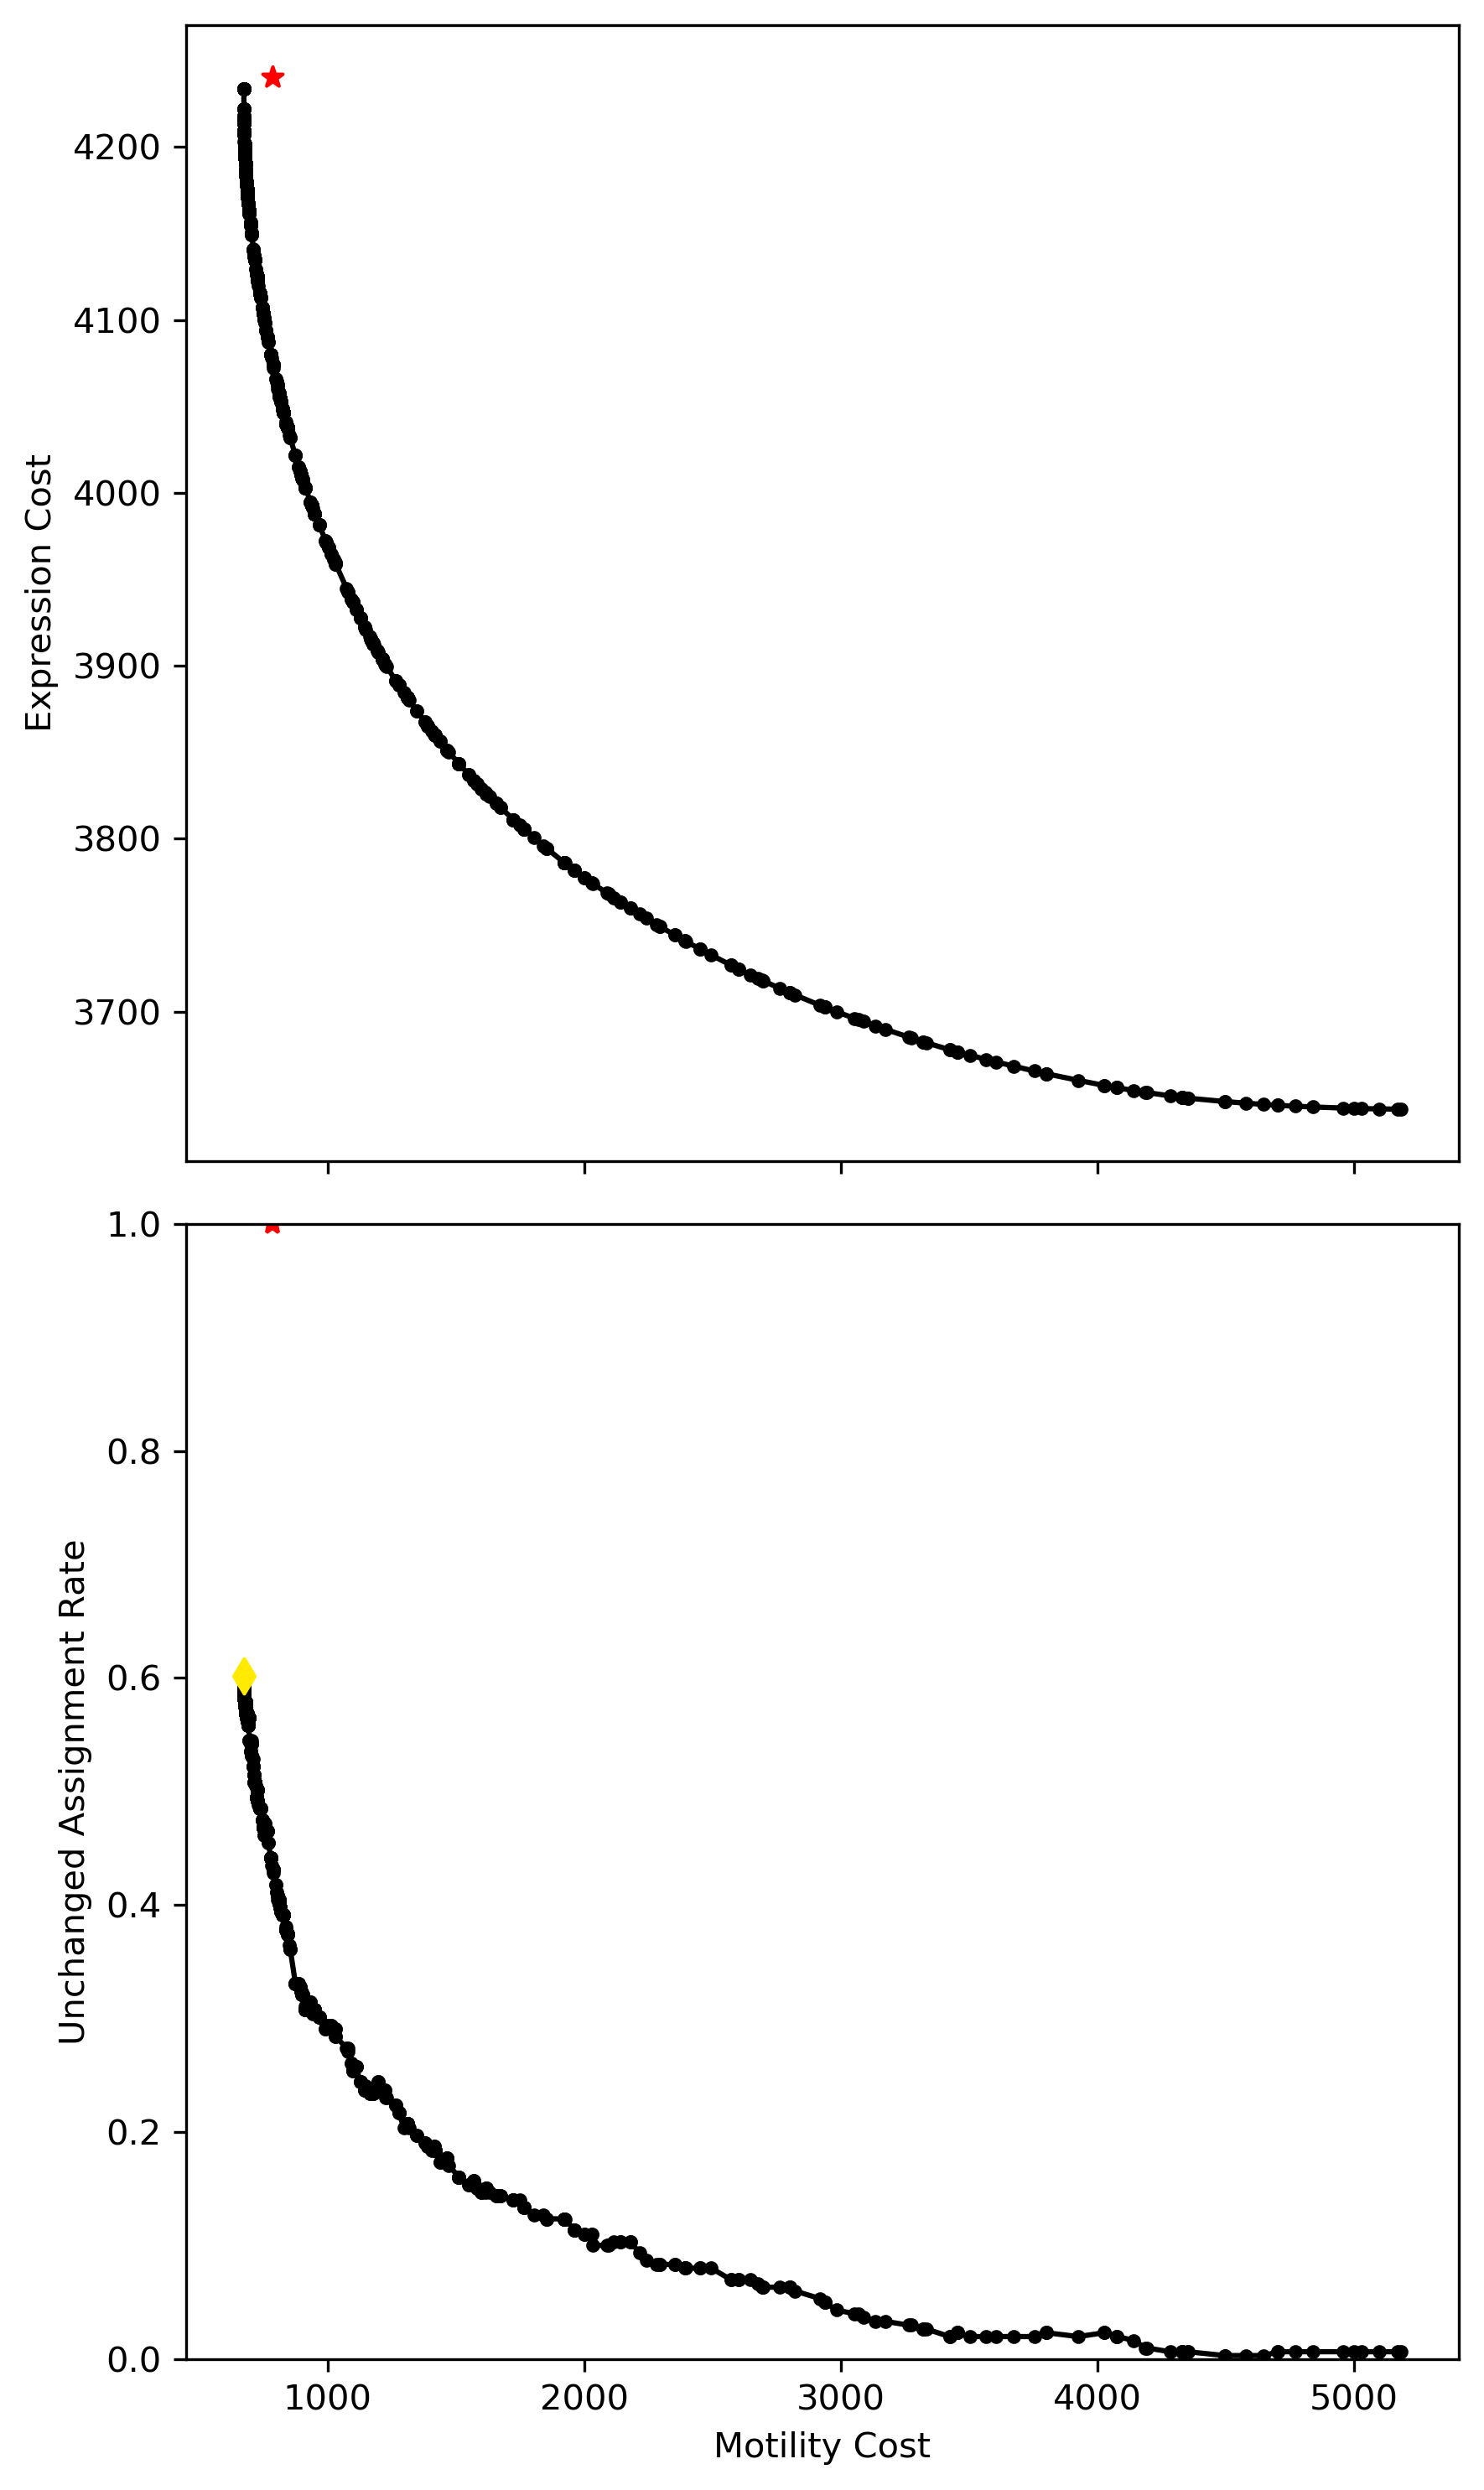

[np.float64(785.8319922117702),
 np.float64(673.6725785725567),
 np.float64(5184.000813294239),
 0.5986622073578596,
 0.006688963210702341,
 np.float64(673.8105096262494),
 0.6020066889632107]

In [67]:
terminal_pareto_by_subtree("P0", exp_df=uniform_gaussian_exp, save_fig=False)

83


100%|██████████| 1001/1001 [00:00<00:00, 3215.27it/s]


239.66930159934122 214.297566801273


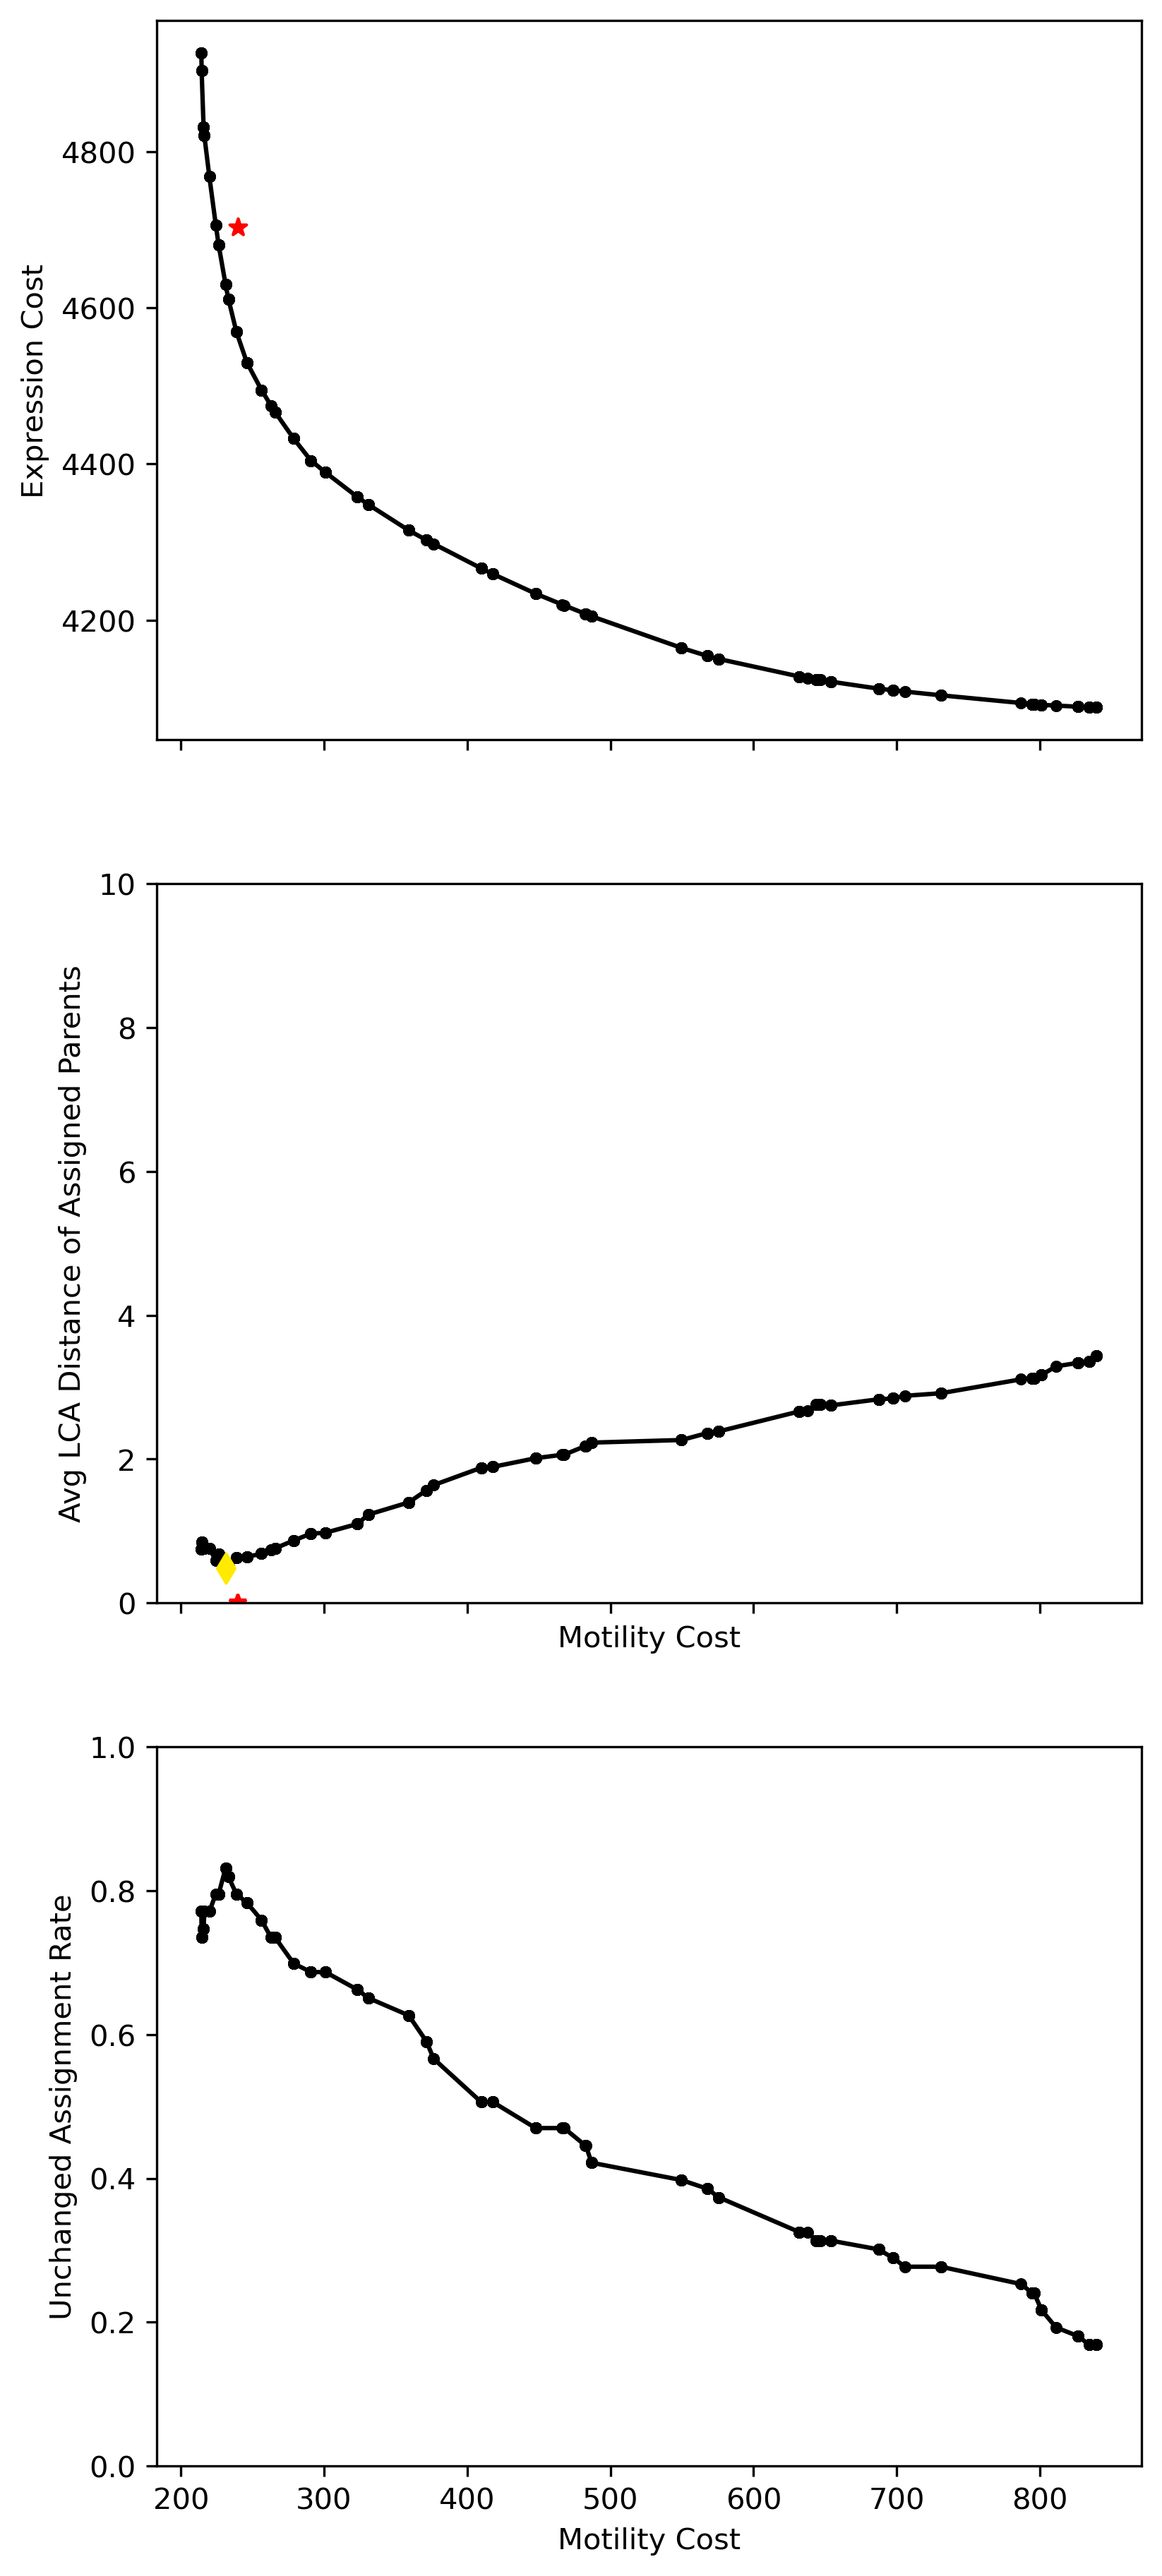

In [ ]:
terminal_pareto_by_subtree("P1", exp_df=protein_exp.loc[candidate_proteins])

In [25]:
def terminal_cousin_group(terminal_ancestry, degree=2):
    lowest_common_ancestor_group = defaultdict(list)
    for terminal_name, ancestry in terminal_ancestry.items():
        if len(ancestry) < degree:
            continue
        lca = ancestry[-degree]
        lowest_common_ancestor_group[lca].append(terminal_name)
    return lowest_common_ancestor_group

In [26]:
terminal_node_cords = []
terminal_parent_cords = []
xyz_coord_dict = {}
exp_vector_dict = {}
alt_exp_vector_dict = {}
# Collect coordinates for terminal nodes and their parents

for node, parent in zip(terminal_nodes, terminal_parents):
    xyz_coord_dict[node] = ts_df.loc[ts_df['name'] == node].values[-1][1:4]*0.1625
    xyz_coord_dict[parent] = ts_df.loc[ts_df['name'] == parent].values[-1][1:4]*0.1625
    exp_vector_dict[node] = protein_exp.loc[:, node].values
    exp_vector_dict[parent] = protein_exp.loc[:, parent].values
    alt_exp_vector_dict[node] = alt_exp_pca_df.loc[:, node].values
    alt_exp_vector_dict[parent] = alt_exp_pca_df.loc[:, parent].values

In [25]:
siblings_exp_distances_with_same_type = []
siblings_exp_distances_with_diff_type = []
sibling_parent_distances_with_same_type = []
sibling_parent_distances_with_diff_type = []
for parent, children in terminal_parents_dict.items():
    child_types = set()
    for child in children:
        child_type = lineage_type_dict.get(child, None)
        if child_type is not None:
            child_types.add(child_type)
    # if len(child_types) == 1 and len(children) > 1:
    #     siblings_exp_distances_with_same_type.append(np.mean([np.linalg.norm(zscored.loc[child1] - zscored.loc[child2]) for i, child1 in enumerate(children) for j, child2 in enumerate(children) if i < j]))
    #     sibling_parent_distances_with_same_type.append(np.mean([np.linalg.norm(zscored.loc[child] - zscored.loc[parent]) for child in children]))
    # elif len(child_types) > 1:
    #     siblings_exp_distances_with_diff_type.append(np.mean([np.linalg.norm(zscored.loc[child1] - zscored.loc[child2]) for i, child1 in enumerate(children) for j, child2 in enumerate(children) if i < j]))
    #     sibling_parent_distances_with_diff_type.append(np.mean([np.linalg.norm(zscored.loc[child] - zscored.loc[parent]) for child in children]))
    
    if len(child_types) == 1 and len(children) > 1:
        siblings_exp_distances_with_same_type.append(np.mean([jsd_matrix_df.loc[child1, child2] for i, child1 in enumerate(children) for j, child2 in enumerate(children) if i < j]))
        sibling_parent_distances_with_same_type.append(np.mean([jsd_matrix_df.loc[child, parent] for child in children]))
    elif len(child_types) > 1:
        siblings_exp_distances_with_diff_type.append(np.mean([jsd_matrix_df.loc[child1, child2] for i, child1 in enumerate(children) for j, child2 in enumerate(children) if i < j]))
        sibling_parent_distances_with_diff_type.append(np.mean([jsd_matrix_df.loc[child, parent] for child in children]))

In [26]:
print(f"Avg sibling expression distance with same type: {np.mean(siblings_exp_distances_with_same_type):.4f}")
print(f"Avg sibling expression distance with different type: {np.mean(siblings_exp_distances_with_diff_type):.4f}")
print(f"Avg sibling-parent expression distance with same type: {np.mean(sibling_parent_distances_with_same_type):.4f}")
print(f"Avg sibling-parent expression distance with different type: {np.mean(sibling_parent_distances_with_diff_type):.4f}")

Avg sibling expression distance with same type: 0.1384
Avg sibling expression distance with different type: 0.1316
Avg sibling-parent expression distance with same type: 0.2081
Avg sibling-parent expression distance with different type: 0.1993


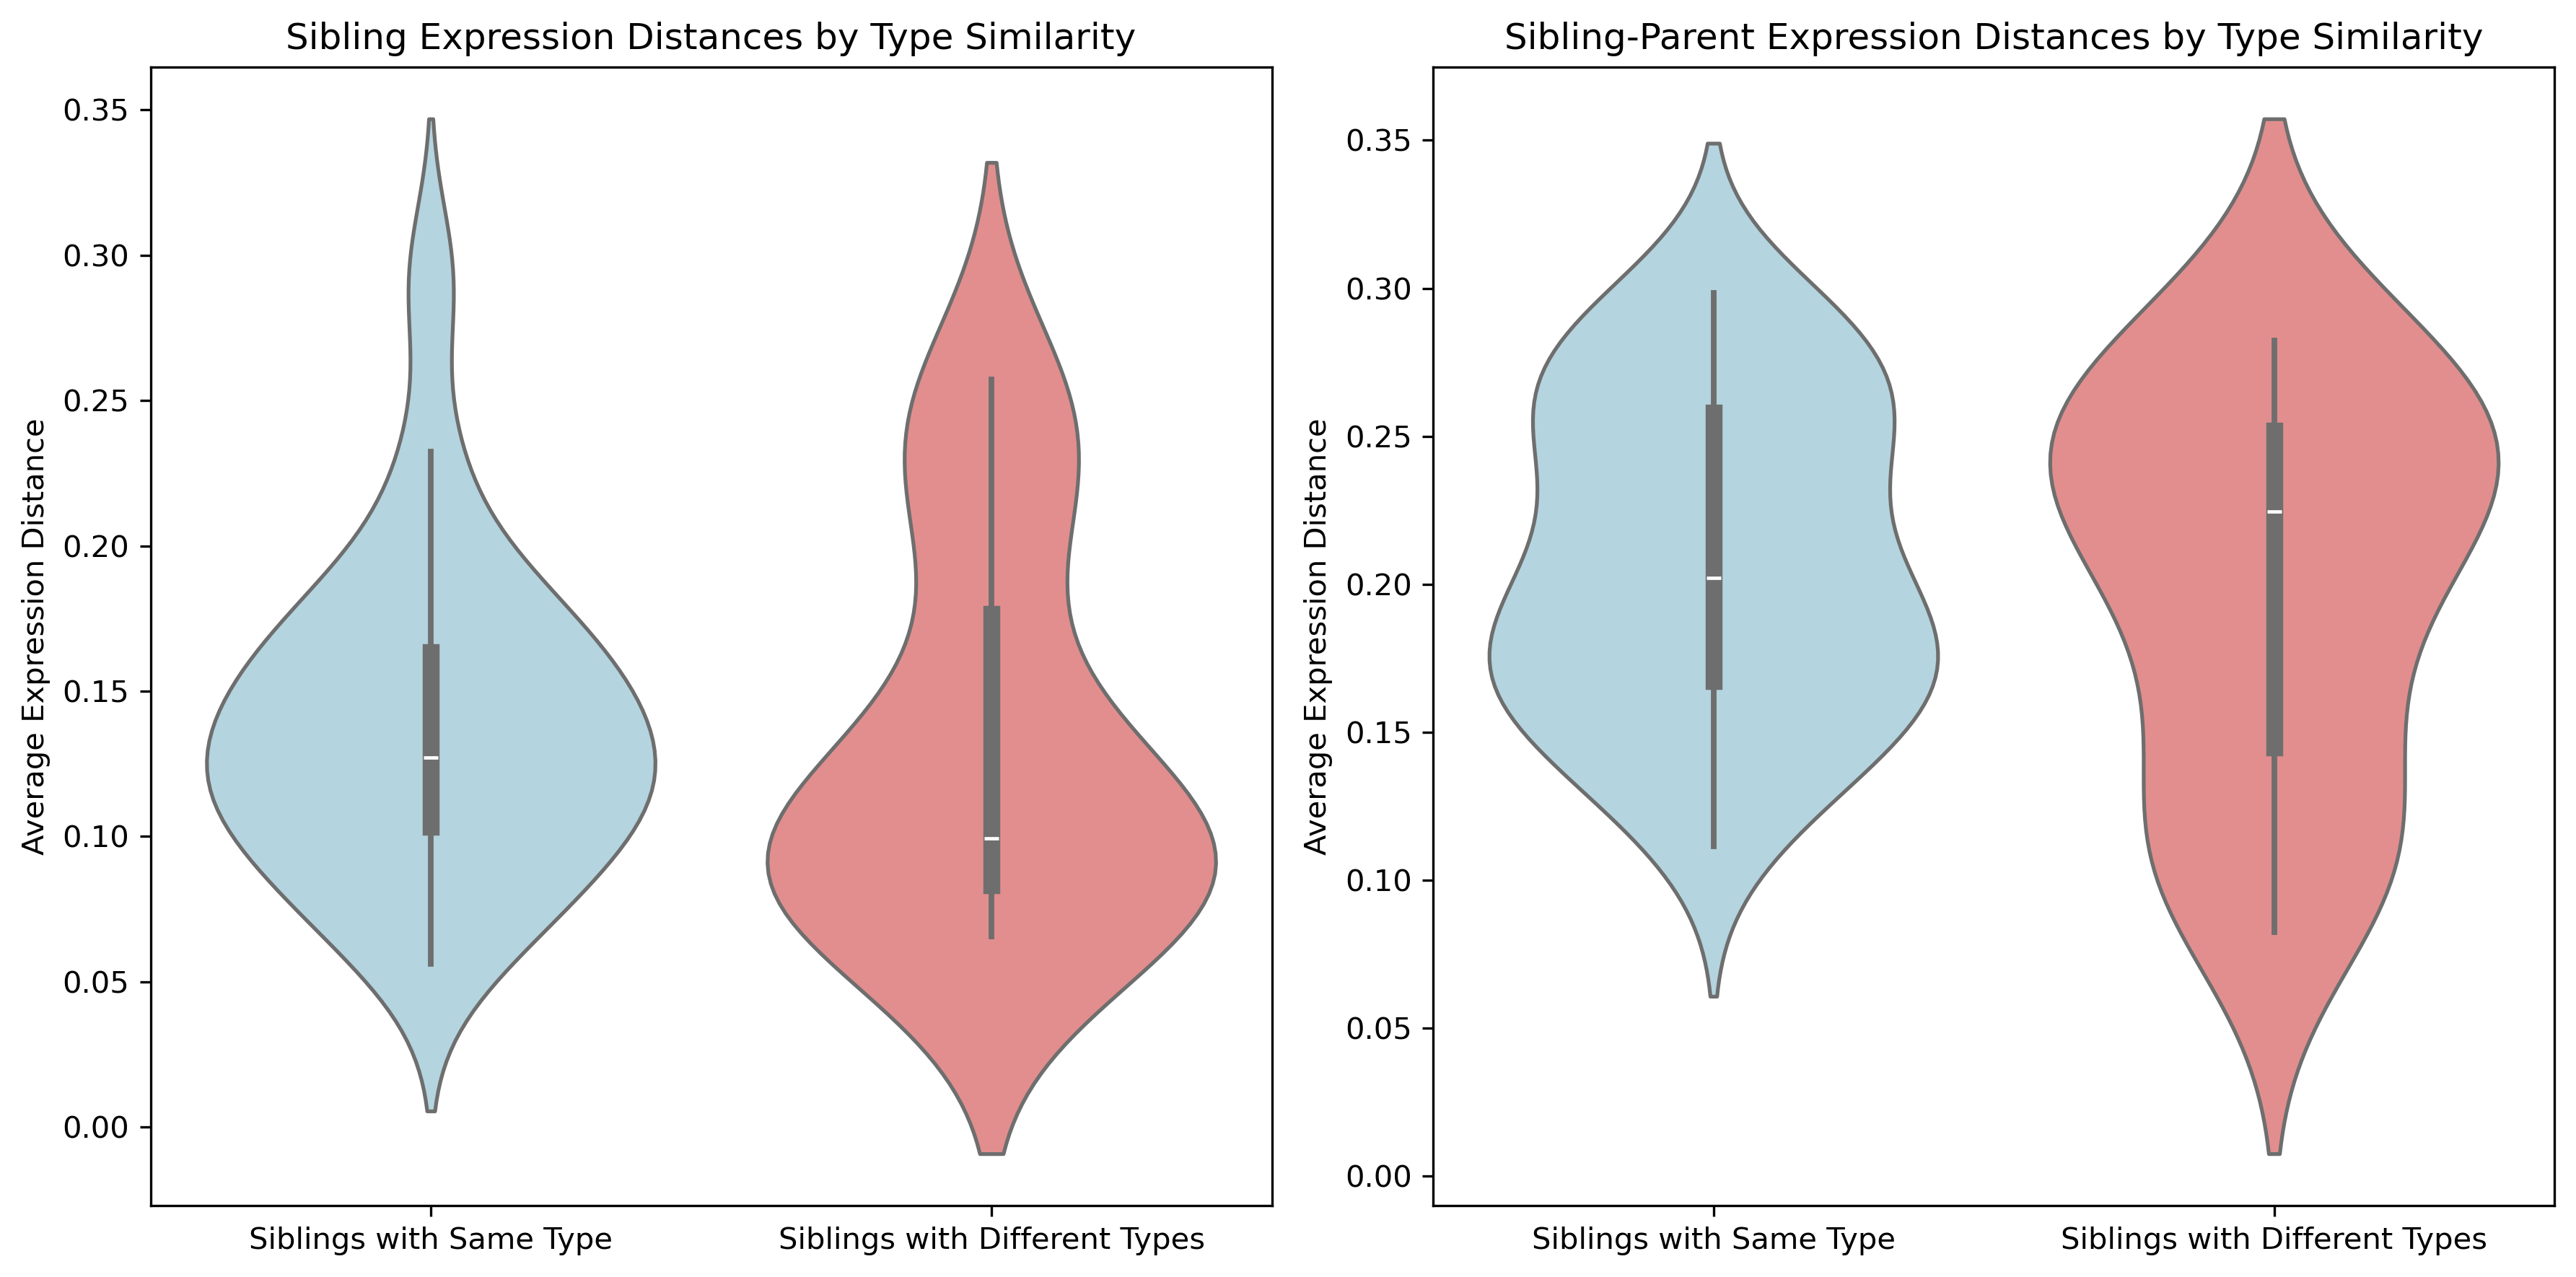

In [27]:
# Plotting the results with seaborn violin plots, grouped by same type vs different type, so 2 boxplots for sibling distances and 2 boxplots for sibling-parent distances
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.violinplot(data=[siblings_exp_distances_with_same_type, siblings_exp_distances_with_diff_type], palette=["lightblue", "lightcoral"])
plt.xticks([0, 1], ['Siblings with Same Type', 'Siblings with Different Types'])
plt.ylabel('Average Expression Distance')
plt.title('Sibling Expression Distances by Type Similarity')
plt.subplot(1, 2, 2)
sns.violinplot(data=[sibling_parent_distances_with_same_type, sibling_parent_distances_with_diff_type], palette=["lightblue", "lightcoral"])
plt.xticks([0, 1], ['Siblings with Same Type', 'Siblings with Different Types'])
plt.ylabel('Average Expression Distance')
plt.title('Sibling-Parent Expression Distances by Type Similarity')
plt.tight_layout()
plt.show()

In [82]:
# some comparison between different expression datasets

xyz_cost_mat = np.zeros((len(terminal_parents), len(terminal_nodes)))
exp_cost_mat = np.zeros((len(terminal_parents), len(terminal_nodes)))
alt_exp_cost_mat = np.zeros((len(terminal_parents), len(terminal_nodes)))
house_keeping_exp_cost_mat = np.zeros((len(terminal_parents), len(terminal_nodes)))
for i, parent in enumerate(terminal_parents):
    for j, node in enumerate(terminal_nodes):
        parent_xyz = xyz_coord_dict[parent]
        node_xyz = xyz_coord_dict[node]
        xyz_cost_mat[i, j] = np.linalg.norm(parent_xyz - node_xyz)
        
        parent_exp = exp_vector_dict[parent]
        node_exp = exp_vector_dict[node]
        exp_cost_mat[i, j] = np.linalg.norm(parent_exp - node_exp)
        
        parent_alt_exp = alt_exp_pca_df[parent].values
        node_alt_exp = alt_exp_pca_df[node].values
        alt_exp_cost_mat[i, j] = np.linalg.norm(parent_alt_exp - node_alt_exp)
        
        parent_house_keeping_exp = random_exp[parent].values
        node_house_keeping_exp = random_exp[node].values
        house_keeping_exp_cost_mat[i, j] = np.linalg.norm(parent_house_keeping_exp - node_house_keeping_exp)
lineage_xyz_cost = xyz_cost_mat.diagonal().sum()
lineage_exp_cost = exp_cost_mat.diagonal().sum()
lineage_alt_exp_cost = alt_exp_cost_mat.diagonal().sum()
lineage_house_keeping_exp_cost = house_keeping_exp_cost_mat.diagonal().sum()

In [83]:
def pareto_exp_comp(chosen_exp_cost, title):
    pareto_xyz_costs = []
    pareto_exp_costs = []
    pareto_alt_exp_costs = []
    pareto_house_keeping_exp_costs = []
    for i in tqdm(range(1001)):
        alpha = i / 1000.0
        combined_cost_mat = alpha * chosen_exp_cost + (1 - alpha) * xyz_cost_mat
        row_ind, col_ind = linear_sum_assignment(combined_cost_mat)
        pareto_xyz_costs.append(xyz_cost_mat[row_ind, col_ind].sum())
        pareto_exp_costs.append(exp_cost_mat[row_ind, col_ind].sum())
        pareto_alt_exp_costs.append(alt_exp_cost_mat[row_ind, col_ind].sum())
        pareto_house_keeping_exp_costs.append(house_keeping_exp_cost_mat[row_ind, col_ind].sum())
    
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6, 10), sharex=True)
    fig.suptitle(title)
    ax1.plot(pareto_xyz_costs, pareto_exp_costs, marker='o', linestyle='-', color='black', markersize=3, label='Pareto Front in Protein Expression Space')
    ax1.scatter(lineage_xyz_cost, lineage_exp_cost, marker='*', color='#FF0000', label='Real Lineage Cost')
    ax1.set_ylabel('Protein-TF Cost')
    ax1.set_xlabel('Motility Cost')
    ax2.plot(pareto_xyz_costs, pareto_alt_exp_costs, marker='o', linestyle='-', color='black', markersize=3, label='Pareto Front in ScRNA Expression Space')
    ax2.scatter(lineage_xyz_cost, lineage_alt_exp_cost, marker='*', color='#FF0000', label='Real Lineage Cost')
    ax2.set_ylabel('ScRNA Cost')
    ax2.set_xlabel('Motility Cost')
    ax3.plot(pareto_xyz_costs, pareto_house_keeping_exp_costs, marker='o', linestyle='-', color='black', markersize=3, label='Pareto Front in House-Keeping Gene Expression Space')
    ax3.scatter(lineage_xyz_cost, lineage_house_keeping_exp_cost, marker='*', color='#FF0000', label='Real Lineage Cost')
    ax3.set_ylabel('House-Keeping Cost')
    ax3.set_xlabel('Motility Cost')
    plt.tight_layout()
    plt.show()

100%|██████████| 1001/1001 [00:01<00:00, 514.30it/s]


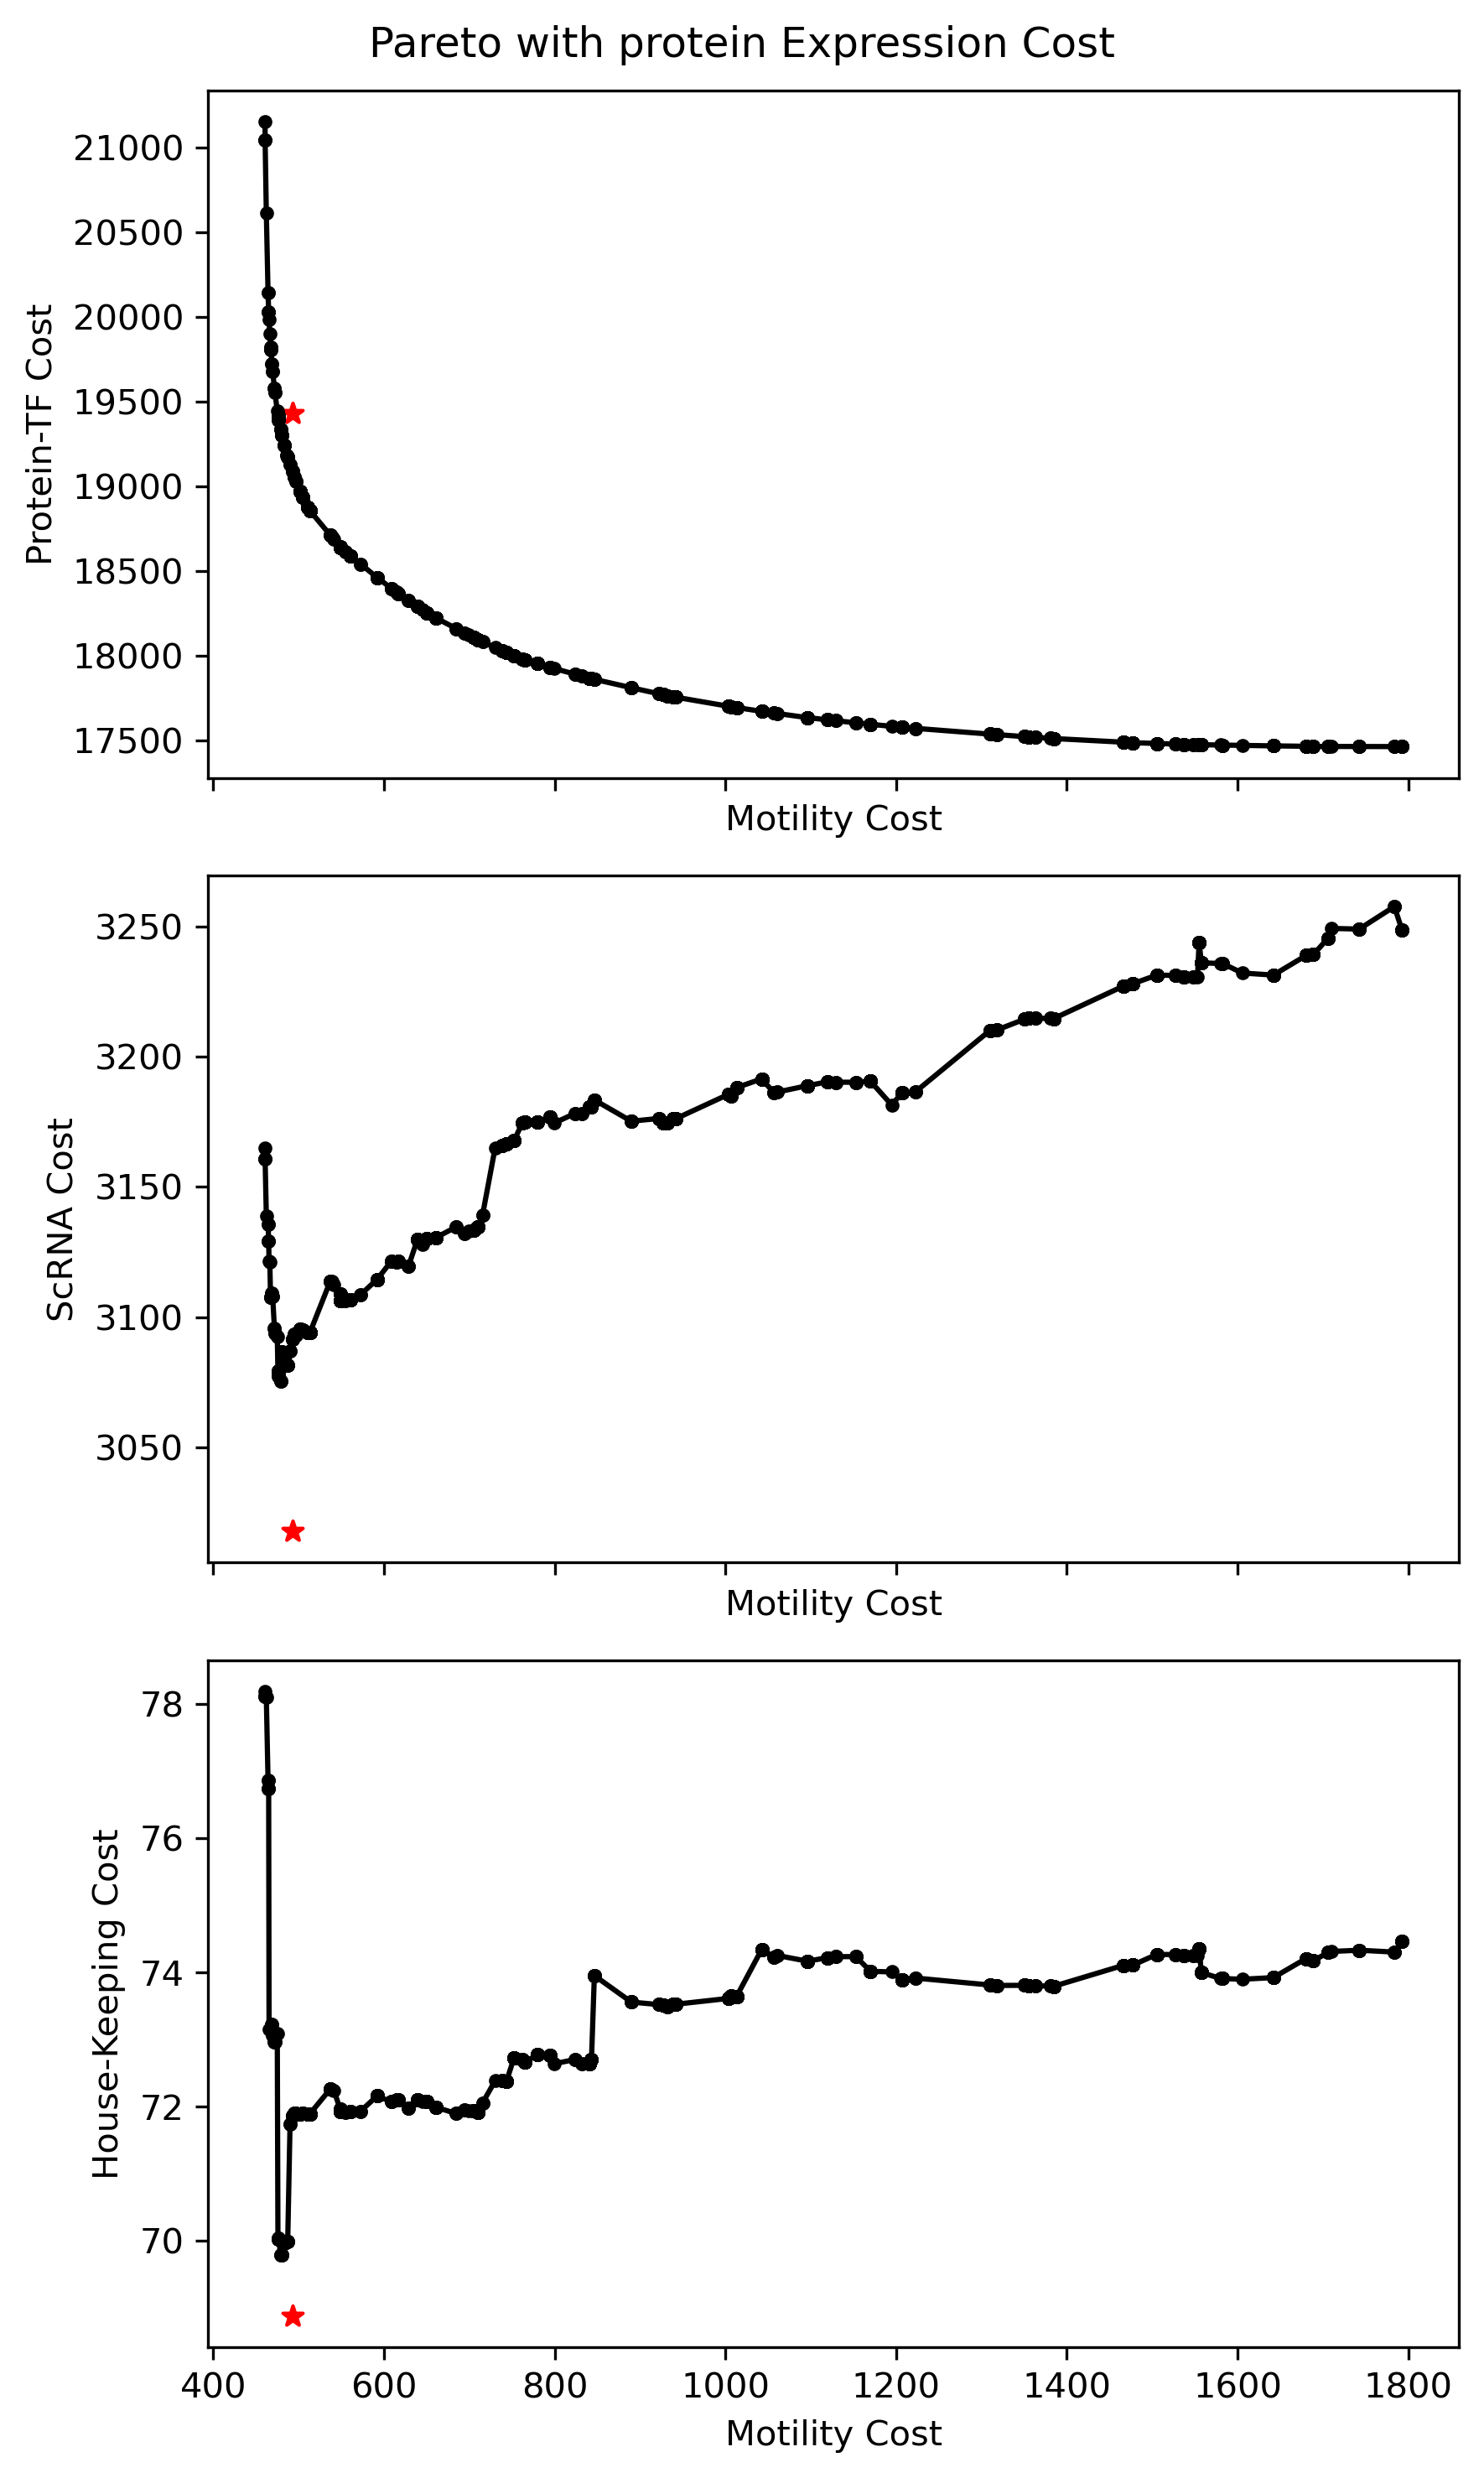

In [68]:
pareto_exp_comp(exp_cost_mat, "Pareto with protein Expression Cost")

In [50]:
new_pf = ParetoFront(terminal_nodes, terminal_parents, terminal_ancestry, xyz_coord_dict, lineage_exp, binary_lineage_exp, binary_lineage_end_exp, title="Pareto Front of 299 Terminal Cells")

In [51]:
xyz_mat, exp_mat = new_pf.compute_cost_matrices()
res = new_pf.compute_pareto_front(xyz_mat, exp_mat, monte_carlo=False, return_lca_distances=True)

100%|██████████| 189/189 [00:00<00:00, 611.20it/s]


0.965 475.76746082489444


100%|██████████| 83/83 [00:00<00:00, 1395.46it/s]


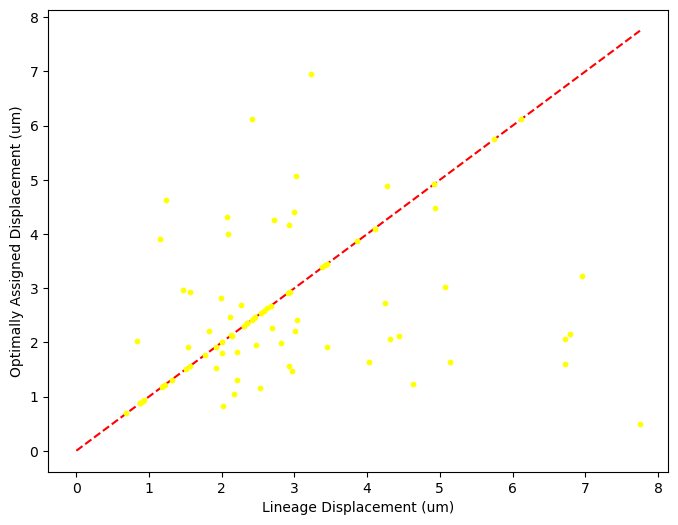

Optimal xyz assignment costs (norm=l2): Motility Cost = 214.297566801273, Expression Cost = 8697.728996180229
number of optimally assigned displacements stayed the same: 34
Top 5 Terminal Nodes with Largest Decrease in Displacement Cost:
Terminal Node: MSpapaaaa, Lineage Parent: MSpapaaa, Optimal Parent: MSpaap, Displacement Difference: -7.2650
Terminal Node: Cpappd, Lineage Parent: Cpapp, Optimal Parent: Cpapa, Displacement Difference: -5.1091
Terminal Node: MSppppap, Lineage Parent: MSppppa, Optimal Parent: MSppapp, Displacement Difference: -4.6514
Terminal Node: Z3, Lineage Parent: P4, Optimal Parent: P4, Displacement Difference: -4.6262
Terminal Node: Cpaaap, Lineage Parent: Cpaaa, Optimal Parent: Cpaaa, Displacement Difference: -3.7260


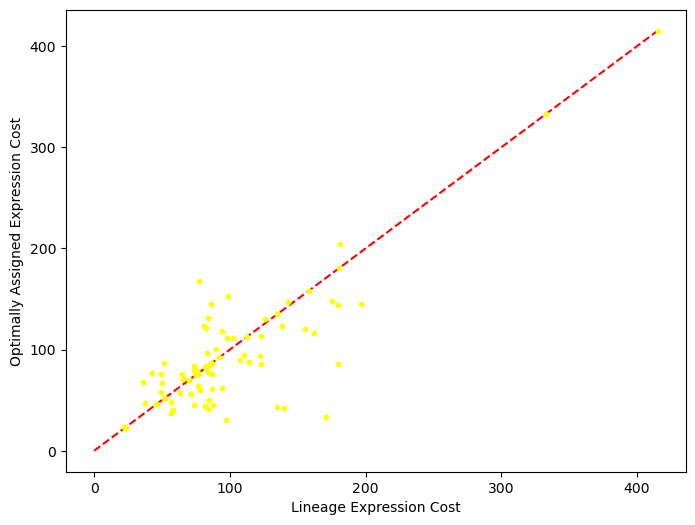

Optimal Expression assignment costs (norm=l2): Expression Cost = 7736.3556772695965, Motility Cost = 714.5633722262168
number of optimally assigned displacements stayed the same: 14
Top 5 Terminal Nodes with Largest Decrease in Expression Cost:
Terminal Node: MSppaapp, Lineage Parent: MSppaap, Optimal Parent: MSapapp, Displacement Difference: -137.5943
Terminal Node: MSpappap, Lineage Parent: MSpappa, Optimal Parent: MSpppap, Displacement Difference: -98.1807
Terminal Node: MSappapa, Lineage Parent: MSappap, Optimal Parent: MSappap, Displacement Difference: -93.3318
Terminal Node: Cpaapa, Lineage Parent: Cpaap, Optimal Parent: Caaap, Displacement Difference: -91.4714
Terminal Node: MSappaaa, Lineage Parent: MSappaa, Optimal Parent: MSapaap, Displacement Difference: -66.8826


Monte Carlo Simulation:   0%|          | 0/1000000 [00:00<?, ?it/s]

Computing random costs by 1st cousins shuffle:   0%|          | 0/100000 [00:00<?, ?it/s]

Computing random costs by 2nd cousins shuffle:   0%|          | 0/100000 [00:00<?, ?it/s]

Computing random costs by 3rd cousins shuffle:   0%|          | 0/100000 [00:00<?, ?it/s]

0.893 231.77476452885224
lineage costs: xyz, 239.66930159934122 exp, 8289.936981953166
bottom right corner: 714.5633722262168 7736.3556772695965
top left corner: 214.297566801273 8697.728996180229
monte carlo costs: xyz, 1205.9505292877272 exp, 13593.085708236706
monte carlo costs std: xyz, 51.79001967047324 exp, 332.8083684578126


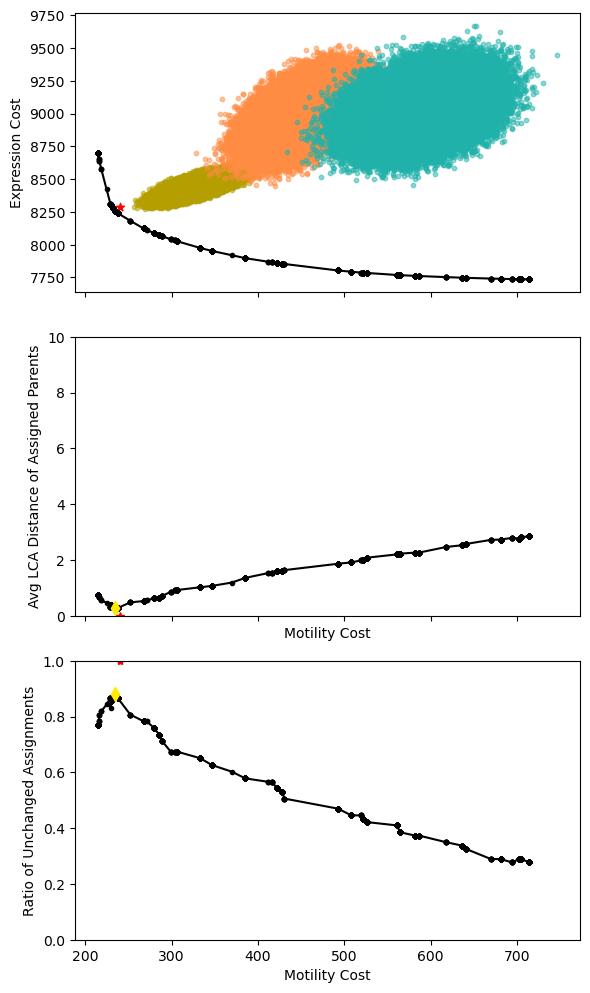

In [65]:
res = new_pf.pre_plot()

In [53]:
xyz_coord_dict['ABalaaapal']

array([18.2, 26.4875, 14.7875], dtype=object)

In [47]:
xyz_cost_mat, exp_cost_mat = new_pf.compute_cost_matrices()

100%|██████████| 248/248 [00:00<00:00, 482.34it/s]


In [48]:
cur_row_ind, cur_col_ind = linear_sum_assignment(xyz_cost_mat)

In [30]:
monte_carlo_list, pareto_xyz_cost_list, pareto_exp_cost_list, lineage_xyz_cost, lineage_exp_cost = res

In [ ]:
monte_carlo_xyz_cost = [item[0] for item in monte_carlo_list]
monte_carlo_exp_cost = [item[1] for item in monte_carlo_list]
monte_carlo_xyz_mean = np.mean(monte_carlo_xyz_cost)
monte_carlo_exp_mean = np.mean(monte_carlo_exp_cost)
monte_carlo_xyz_std = np.std(monte_carlo_xyz_cost)
monte_carlo_exp_std = np.std(monte_carlo_exp_cost)

print((monte_carlo_xyz_mean - lineage_xyz_cost) / monte_carlo_xyz_std, (monte_carlo_exp_mean - lineage_exp_cost) / monte_carlo_exp_std)
print((monte_carlo_xyz_mean - np.min(pareto_xyz_cost_list)) / monte_carlo_xyz_std, (monte_carlo_exp_mean - np.min(pareto_exp_cost_list)) / monte_carlo_exp_std)


43.730214517960704 50.18799286493368
49.61225039266454 56.22062423232257


In [36]:
from scipy.stats import norm
norm.cdf(40)

np.float64(1.0)

100%|██████████| 248/248 [00:00<00:00, 267.58it/s]



Computing cost matrices with expression norm: L1


<string>:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


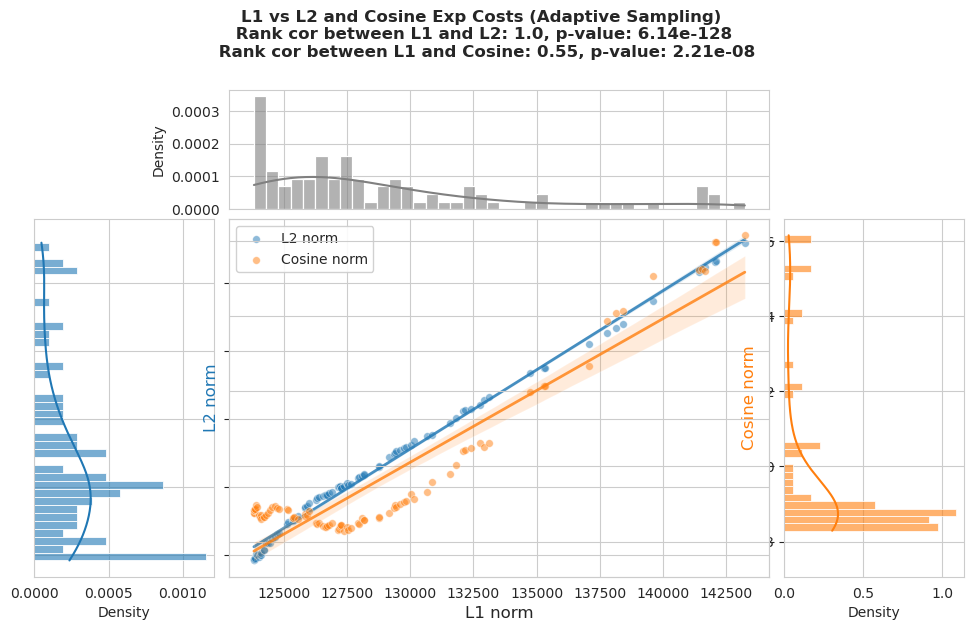

unique number of L1 cost values: 89
Computing cost matrices with expression norm: L2


<string>:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


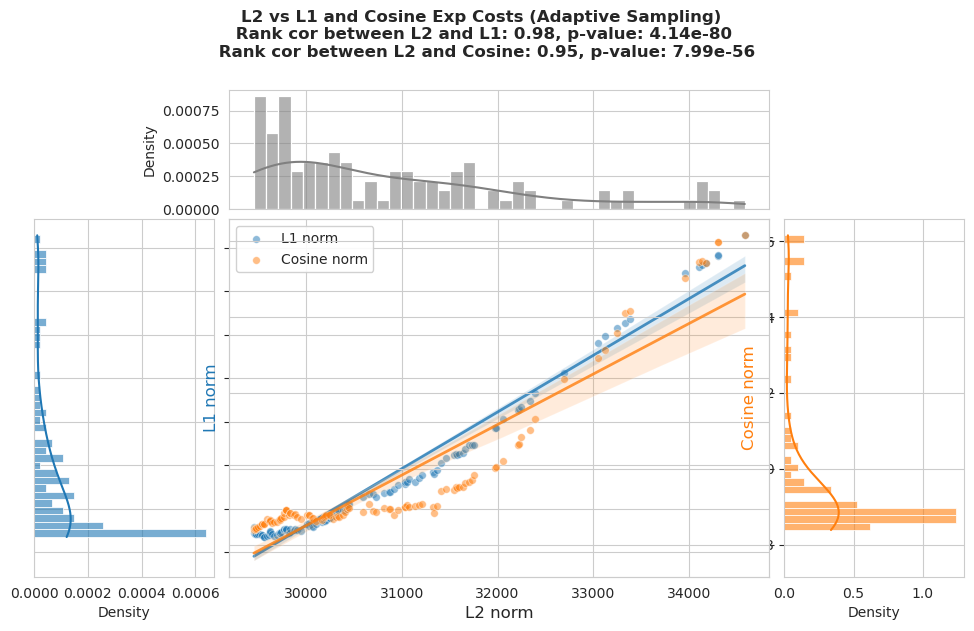

unique number of L2 cost values: 108
Computing cost matrices with expression norm: Cosine


<string>:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


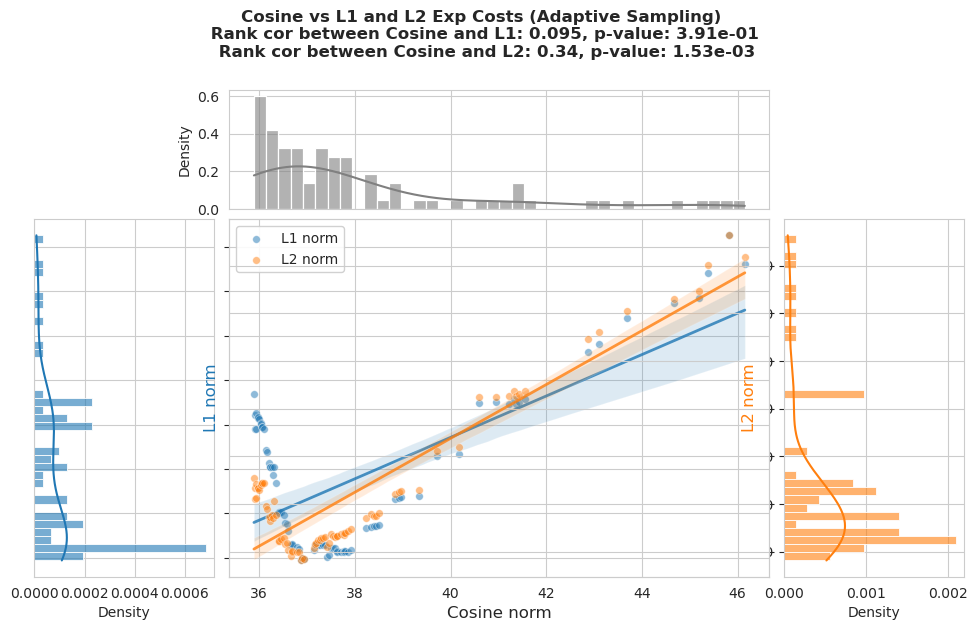

unique number of Cosine cost values: 84


In [45]:
res = new_pf.norm_comp_with_adaptive_sampling()

100%|██████████| 248/248 [00:00<00:00, 266.34it/s]



Computing cost matrices with expression norm: l1


<string>:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


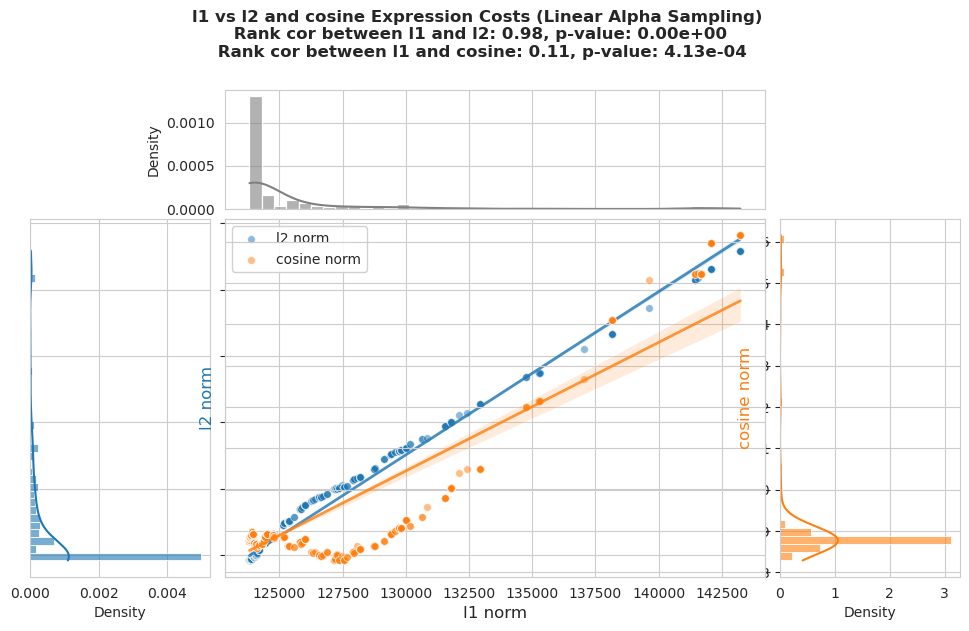

unique number of l1 cost values: 142
Computing cost matrices with expression norm: l2


<string>:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


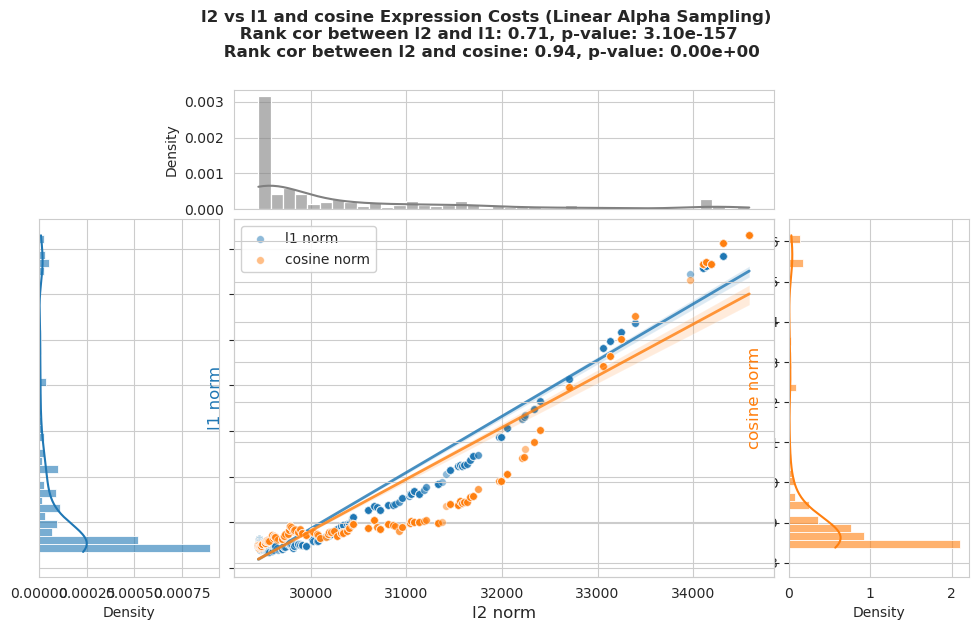

unique number of l2 cost values: 201
Computing cost matrices with expression norm: cosine


<string>:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


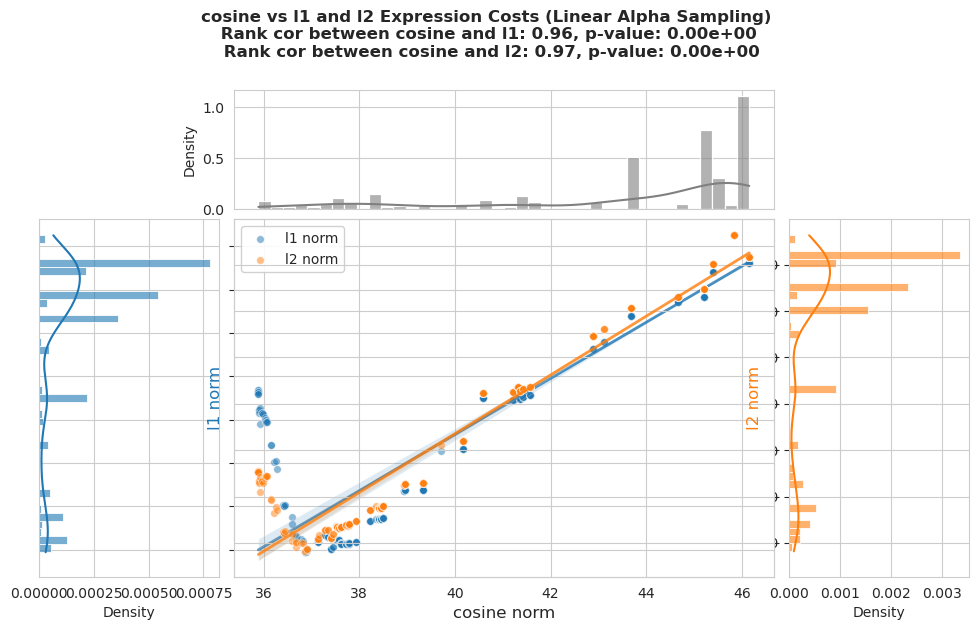

unique number of cosine cost values: 101


In [46]:
l2_cost_list, cosine_cost_list = new_pf.norm_comp()

In [ ]:
from scipy.spatial import KDTree

In [ ]:
kd_tree = KDTree(lineage_exp.T)


In [57]:
lineage_exp.sum()

cell
ABa        123.10
ABal       370.06
ABala      395.98
ABalaa     414.86
ABalaaa    710.05
            ...  
P2         317.11
P3         361.52
P4         289.33
Z2         302.14
Z3         318.65
Length: 1204, dtype: float64

In [50]:
kd_tree.query(np.zeros(291))

(46.53861622351915, np.int64(862))

In [52]:
x, y = np.mgrid[0:5, 2:8]
tree = KDTree(np.c_[x.ravel(), y.ravel()])
dd, ii = tree.query([[0, 0], [2.2, 2.9]], k=1)
print(dd, ii)

[2.        0.2236068] [ 0 13]


Computing cost matrices with norm: l1


100%|██████████| 248/248 [00:00<00:00, 325.94it/s]


Monte Carlo Simulation:   0%|          | 0/1000 [00:00<?, ?it/s]

950.4625000000001


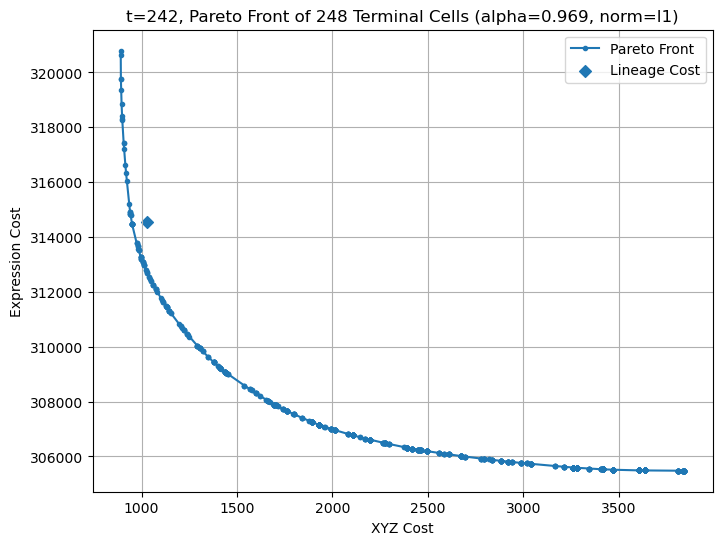

Computing cost matrices with norm: l2


100%|██████████| 248/248 [00:00<00:00, 408.43it/s]


Monte Carlo Simulation:   0%|          | 0/1000 [00:00<?, ?it/s]

633.6002680687883


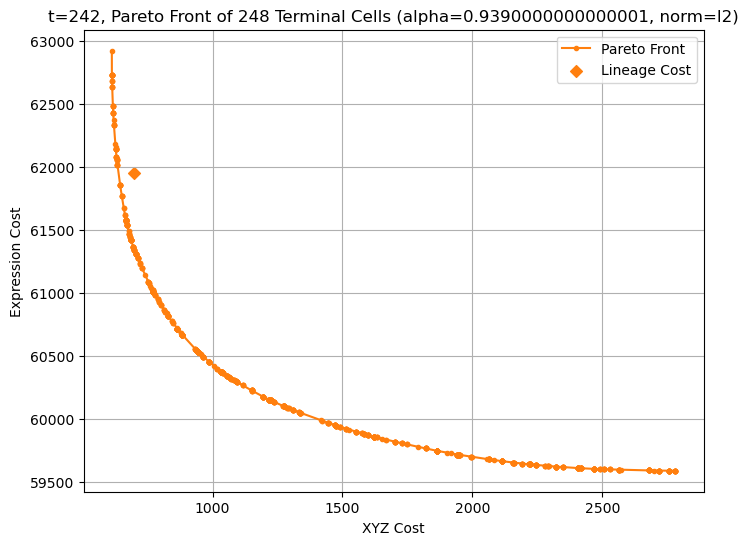

Computing cost matrices with norm: cosine


100%|██████████| 248/248 [00:00<00:00, 279.66it/s]


Monte Carlo Simulation:   0%|          | 0/1000 [00:00<?, ?it/s]

0.234885013741023


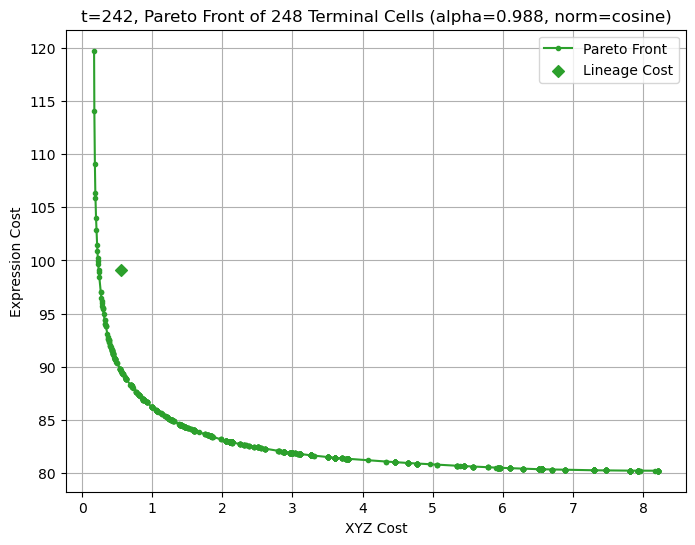

Computing cost matrices with norm: l2+cosine


100%|██████████| 248/248 [00:00<00:00, 344.07it/s]


Monte Carlo Simulation:   0%|          | 0/1000 [00:00<?, ?it/s]

646.477105189015


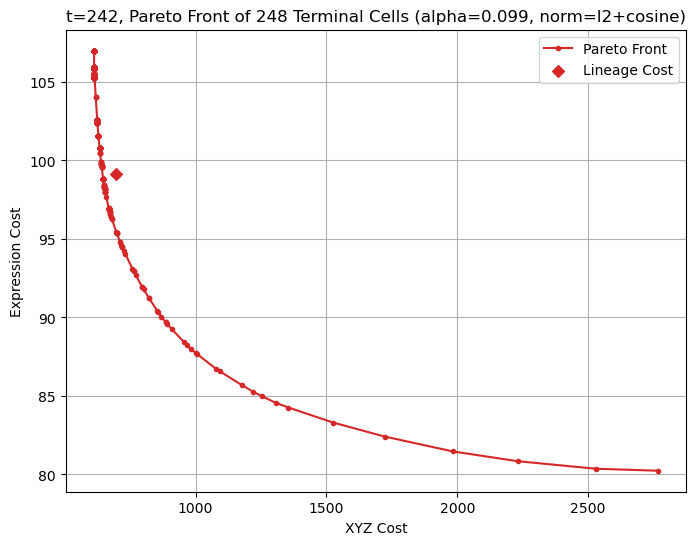

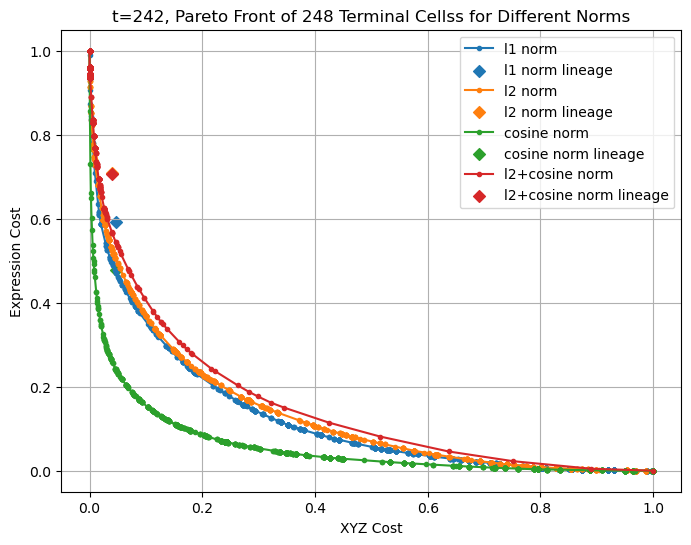

In [181]:
new_pf.normal_run()

In [23]:
sns.color_palette(n_colors=3)

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313)]

In [ ]:
def terminal_trajectory(terminal_node):
    ''' 
    using ipyvolume plot the lineage trajectory with directed arrow a terminal node in 3d plot
    the first few ancestors in each terminal's lineage may not have physical coordinates
    start from the first ancestor with physical coordinates
    '''
    if terminal_node not in terminal_nodes:
        print(f"Terminal node {terminal_node} not found in terminal nodes.")
        return
    ancestors = terminal_ancestry[terminal_nodes.index(terminal_node)]
    coordinates = []
    for ancestor in ancestors:
        if ancestor in all_xyz_map:
            coordinates.append(all_xyz_map[ancestor])
    if not coordinates:
        print(f"No physical coordinates found for ancestors of terminal node {terminal_node}.")
        return
    coordinates = np.array(coordinates)
    return coordinates

temp_coordinates = terminal_trajectory("ABprpppapaa").astype(float)
fig = ipv.figure()
x, y, z = temp_coordinates[:, 0], temp_coordinates[:, 1], temp_coordinates[:, 2]
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()
z_min, z_max = z.min(), z.max()
ipv.xlim(x_min, x_max)
ipv.ylim(y_min, y_max)
ipv.zlim(z_min, z_max)
dx = np.diff(temp_coordinates[:, 0])
dy = np.diff(temp_coordinates[:, 1])
dz = np.diff(temp_coordinates[:, 2])
ipv.quiver(temp_coordinates[:-1, 0], temp_coordinates[:-1, 1], temp_coordinates[:-1, 2], dx, dy, dz, 
          color='red', arrow_length_ratio=0.1, size=10)
ipv.plot(x, y, z, marker='o', linestyle='-', color='blue', size=2)
ipv.show()

In [ ]:
# for every terminal node, plot the trajectory
# save the plot to output/xyz_trajectories/{node_name}.png
import os
output_dir = "output/xyz_trajectories"
os.makedirs(output_dir, exist_ok=True)
for terminal_node in tqdm(terminal_nodes):
    fig = terminal_trajectory(terminal_node)
    if fig:
        fig.savefig(os.path.join(output_dir, f"{terminal_node}.png"))
        plt.close(fig)  # Close the figure to free memory


In [ ]:
pair_count = 0
diff_type_count = 0
for parent, children in terminal_parents_dict.items():
    if len(children) > 1:
        pair_count += 1
        type_0 = lineage_type_dict[children[0]]
        type_1 = lineage_type_dict[children[1]]
        if type_0 != type_1:
            diff_type_count += 1

for node in terminal_nodes:
    if len(lineage_type_dict[node]) == 0:
        print(f"Node {node} has no lineage type.")
```